# <u>Simple Linear Regression</u>

## Topics

* [1. Problem setup](#setup)
* [2. Assumptions for Simple Linea Regression](#assume)
* [3. Core Minimization problem (OLS)](#min)
* [4. Model Quality](#quality)
* [5. Statistical Inference](#stats)
* [6. (Batch) Gradient Descent](#gd)
* [7. Stochastic Gradient Descent (SGD)](#sgd)



    



<a class="anchor" id="setup"></a>
## 1. Problem setup

In this notebook, I will introduce **Simple Linear Regression** to predict house prices based on the **size of a house**.

The goal is to learn the relationship between **house size (feature)** and **house price (target variable)** using a linear model.

### Variables

* **Size** $-$ Size of the house (input feature)
* **Price** $-$ Price of the house (target variable)

In real life the model looks like this:

$$
\text{Price}_i = \beta_0 + \beta_1 \cdot \text{Size}_i + \varepsilon_i \hspace{2 mm} \text{ for each of the } n \text{ houses }
$$

where $\varepsilon_i$ is an error term for each house distorting the true relationship between Price and Size.

The model will learn a relationship of the form:

$$
\widehat{\text{Price}_i} = \hat{\beta_0} + \hat{\beta_1} \cdot \text{Size}_i 
$$

where **$\hat{\beta_1}$** is the estimated slope,**$\hat{\beta_0}$**  the estimated intercept and $\widehat{\text{Price}_i}$ the predicted *Price* for a (new) house based on their *Size*.

It is common to rewrite the model in matrix form

$$
 \underbrace{\begin{pmatrix} \text{Price}_1 \\ \text{Price}_2 \\ \vdots \\ \text{Price}_n \end{pmatrix}}_{\text{denoted with }y} 
=  \underbrace{\begin{pmatrix} 1 & \text{Size}_1 \\ 1 &  \text{Size}_2 \\ \vdots & \vdots \\ 1 & \text{Size}_n \end{pmatrix}}_{\text{denoted with }X} 
 \underbrace{\begin{pmatrix} \beta_0 \\ \beta_1 \end{pmatrix}}_{=: \beta} +  \underbrace{\begin{pmatrix} \varepsilon_1 \\ \varepsilon_2 \\ \vdots \\ \varepsilon_n \end{pmatrix}}_{=: \varepsilon} 
$$

and therefor predictions can be expressed as 

$$
 \underbrace{\begin{pmatrix} \widehat{\text{Price}_1} \\ \widehat{\text{Price}_2} \\ \vdots \\ \widehat{\text{Price}_n} \end{pmatrix}}_{\text{denoted with }\hat{y}} 
=  \underbrace{\begin{pmatrix} 1 & \text{Size}_1 \\ 1 &  \text{Size}_2 \\ \vdots & \vdots \\ 1 & \text{Size}_n \end{pmatrix}}_{\text{denoted with }X} 
 \underbrace{\begin{pmatrix} \hat{\beta_0} \\ \hat{\beta_1} \end{pmatrix}}_{=: \hat{\beta}} 
$$


>**Note1:** $X$ is called the **Regression matrix** or **Designmatrix** 


>**&#10071;Note2:** <br>
>In simple linear regression, the **intercept does not always have a meaningful interpretation**.  
> For example, when predicting **house prices based on their size in square meters**, the intercept represents the predicted price when the size is **0 square meters**. In reality, a house with 0 square meters does not exist and there are also no **negative square meters**. Therefore, the intercept often has no practical interpretation in such cases.  
> The **slope coefficient** is usually the more interesting parameter because it tells us **how much the price increases for each additional square meter of house size**.


In [2]:
import numpy as np # for working with numpy arrays
import matplotlib.pyplot as plt # for plotting
import pandas as pd  # for importing,exporting,creating and working with dataframes
import scipy.stats as stats # for Q-Q Plot
import statsmodels.api as sm # for Statistical Inference

<a class="anchor" id="assume"></a>
## 2. Assumptions for Simple Linear Regression

| Assumption               | Description                                                                 | Affects $\hat{\beta_0}$ and $\hat{\beta_1}$ | Affects Statistical Inference | Verification                          |
|--------------------------|-----------------------------------------------------------------------------|---------------------------|--------------------------------------|-----------------------------------------------|
| Linearity               | Relationship between $X$ (aka Size) and $y$ (aka Price) is linear.                                     | &#9989;                       | &#9989;                                  | Residuals vs. Fitted Plot, Scatterplot of $X$ (aka Size) and $y$ (aka Price)                    |
| Independent errors            | Errors are independent from each other.                                     | &#10060;                        | &#9989;                                  | Residuals vs. Order Plot |
| Homoscedasticity        | Constant variance of errors across values of $X$.                              | &#10060;                         | &#9989;                                  | Residuals vs. Fitted Plot                     |
| Normality of Errors  $\varepsilon_i \sim \mathcal{N}(0,\sigma^2)$     | Residuals follow a normal distribution.                                      | &#10060;                          | &#9989;                                  | Q-Q Plot of residuals, Histogram of Residuals                         |
| No Extreme Outliers     | Influential observations should not dominate the model. | &#9989;            | &#9989;                                  | Boxplot of $X$ and $y$, Residuals vs. Fitted Plot |



### Linearity

Simple linear regression assumes linearity because it tries to fit a straight line. If the relationship between the feature and target is not roughly linear, the line cannot model it well. Linear means that if one variable increases the other should also increase or decrease. This kind of elationship should be visible when plotting the data.

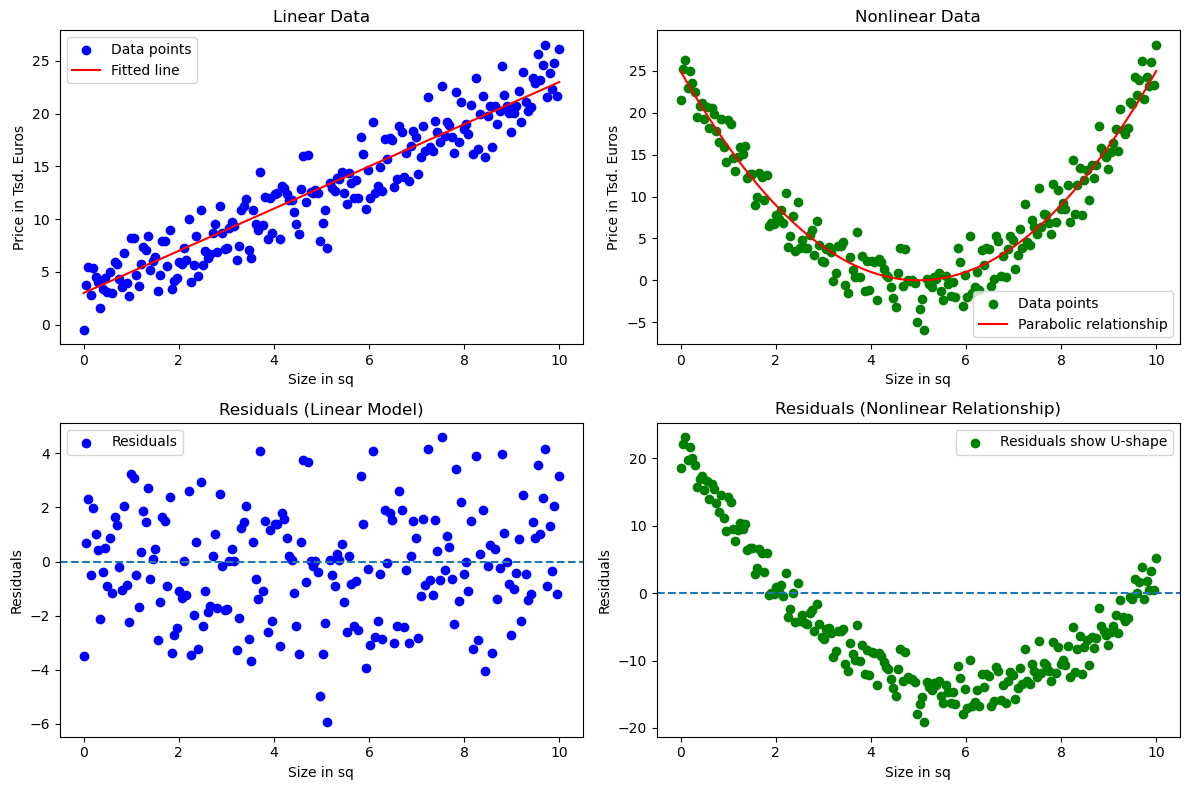

In [3]:
np.random.seed(100)  # Seed for reproducibility of random numbers

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in square meters

# Linear Data
beta_0, beta_1 = 3, 2 # true coefficients
error = np.random.normal(0, 2, n) # error terms to distort true relationship
true_price_linear = beta_0 + beta_1 * size # true relationship between Price and Size
price_linear = true_price_linear + error # distorted relationship between Price and Size


# Nonlinear Data 
true_price_nonlinear = (size - 5)**2 # true relationship between Price and Size
price_nonlinear = true_price_nonlinear + error # distorted relationship between Price and Size


# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Linear data plot
axes[0,0].scatter(size, price_linear, color='blue', label='Data points')
axes[0,0].plot(size, true_price_linear, color='red', label='Fitted line')
axes[0,0].set_title("Linear Data")
axes[0,0].set_xlabel("Size in sq")
axes[0,0].set_ylabel("Price in Tsd. Euros")
axes[0,0].legend()

# Nonlinear data plot
axes[0,1].scatter(size, price_nonlinear, color='green', label='Data points')
axes[0,1].plot(size, true_price_nonlinear, color='red', label='Parabolic relationship')
axes[0,1].set_title("Nonlinear Data")
axes[0,1].set_xlabel("Size in sq")
axes[0,1].set_ylabel("Price in Tsd. Euros")
axes[0,1].legend()


# Residuals
res_linear = price_linear - true_price_linear

# compare nonlinear data to a linear fit to show that a linear model is inappropriate (U-shaped residual pattern)
res_nonlinear = price_nonlinear - true_price_linear # use true_price_linear instead of true_price_nonlinear

# Plot Residuals of linear model
axes[1,0].scatter(size, res_linear, color="blue", label="Residuals")
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals (Linear Model)")
axes[1,0].set_xlabel("Size in sq")
axes[1,0].set_ylabel("Residuals")
axes[1,0].legend()

# Plot Residuals of non-linear model
axes[1,1].scatter(size, res_nonlinear, color="green", label="Residuals show U-shape")
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Residuals (Nonlinear Relationship)")
axes[1,1].set_xlabel("Size in sq")
axes[1,1].set_ylabel("Residuals")
axes[1,1].legend()


plt.tight_layout()
plt.show()

### Independent errors

Dependent errors occur when one data point is influenced by or correlated with another. Mathematically this means $\mathrm{Cov}(\varepsilon_i, \varepsilon_j) \neq 0$ for $i \neq j$.

Example:
- House prices in the same neighborhood that trend together
- Stock prices over consecutive days (time series data)


How It Affects the Model:

- Statistical inference becomes unreliable

    - Standard errors, t-tests, p-values, and confidence intervals assume independence.

Diagnostic:
- Residual vs Orders Plot


Covariance of consecutive independent errors (closer to 0): 0.1348
Covariance of consecutive dependent errors: 1.8722


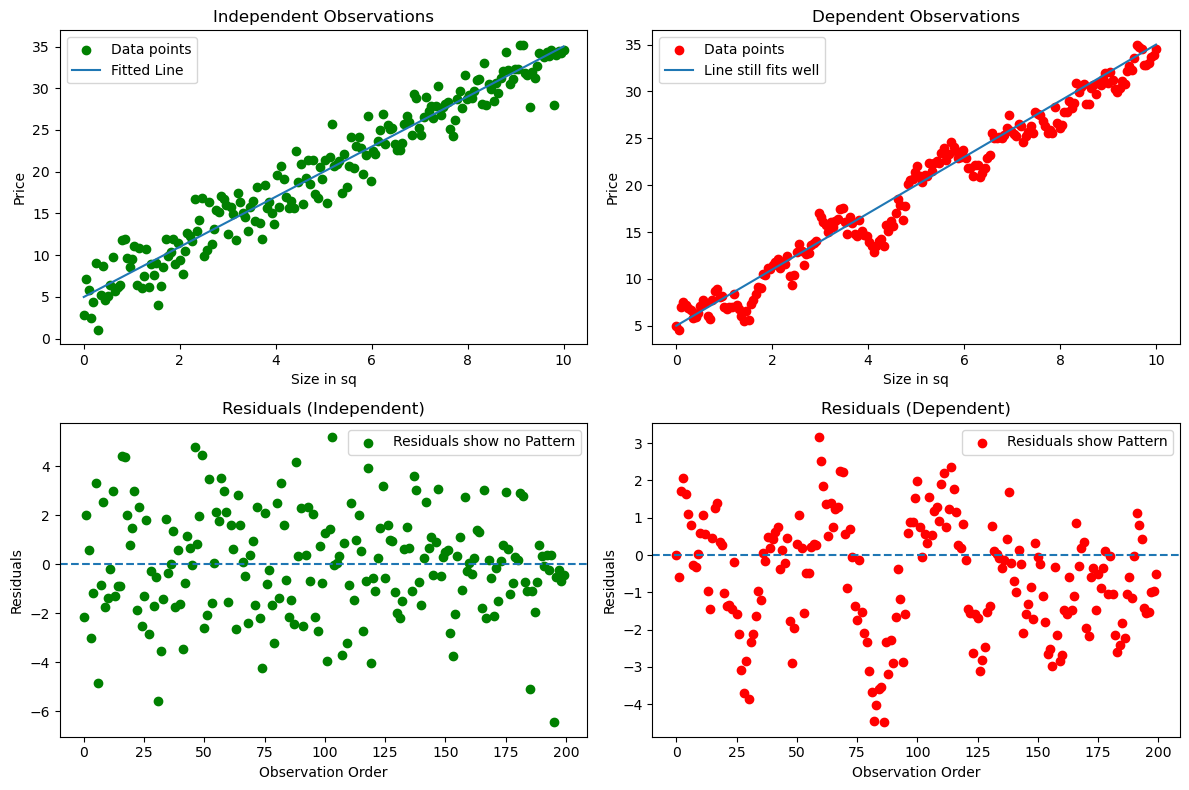

In [4]:
np.random.seed(123) # for reproducibility of random numbers

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in sq

beta_0, beta_1 = 5, 3 # true coefficients

price_true = beta_0 + beta_1 * size # true relationship between price and size

errors_ind = np.random.normal(0, 2, n) # Independent errors

price_ind = price_true + errors_ind # distorted relationship between price and size using independent errors

# Dependent errors by creating autocorrelated errors (AR(1))
rho = 0.8
errors_dep = np.zeros(n)
noise = np.random.normal(0, 1, n)

for t in range(1, n):
    errors_dep[t] = rho * errors_dep[t-1] + noise[t] # next error depends on previous one with formula error_i = p*error_i-1 + noise


price_dep = price_true + errors_dep # distorted relationship between price and size using dependent errors


# Covariance between consecutive errors
cov_ind = np.cov(errors_ind[:-1], errors_ind[1:])[0, 1]
cov_dep = np.cov(errors_dep[:-1], errors_dep[1:])[0, 1]

print(f"Covariance of consecutive independent errors (closer to 0): {cov_ind:.4f}")
print(f"Covariance of consecutive dependent errors: {cov_dep:.4f}")

# Plot 
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Independent data
axes[0,0].scatter(size, price_ind,color="green",label="Data points")
axes[0,0].plot(size, price_true,label="Fitted Line")
axes[0,0].set_title("Independent Observations")
axes[0,0].set_ylabel("Price")
axes[0,0].set_xlabel("Size in sq")
axes[0,0].legend()

# Dependent data
axes[0,1].scatter(size, price_dep,color="red",label="Data points")
axes[0,1].plot(size, price_true,label="Line still fits well")
axes[0,1].set_title("Dependent Observations")
axes[0,1].set_ylabel("Price")
axes[0,1].set_xlabel("Size in sq")
axes[0,1].legend()

# Residuals
res_ind = price_ind - price_true
res_dep = price_dep - price_true

# Independent residuals
axes[1,0].scatter(range(n), res_ind,color="green",label="Residuals show no Pattern")
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals (Independent)")
axes[1,0].set_ylabel("Residuals")
axes[1,0].set_xlabel("Observation Order")
axes[1,0].legend()

# Dependent residuals
axes[1,1].scatter(range(n), res_dep,color="red",label="Residuals show Pattern")
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Residuals (Dependent)")
axes[1,1].set_ylabel("Residuals")
axes[1,1].set_xlabel("Observation Order")
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Homoscedasticity

The variance of the errors $\varepsilon_i$ is constant across all values of the predictor *Size*.
$$
\mathrm{Var}(\varepsilon_i \mid \text{Size}_i) = \sigma^2 \text{ for every house}
$$

Why it matters:

- If the variance changes with *Size* (called heteroskedasticity), the coefficients $\beta_0$ and $\beta_1$ stay valid, but the standard errors, confidence intervals, and p-values become unreliable.

How to check:

- Plot residuals vs. fitted values: A roughly horizontal "cloud" of points indicate homoskedasticity.
- A funnel shape (wider spread at large/small values of *Size*) indicates heteroskedasticity.

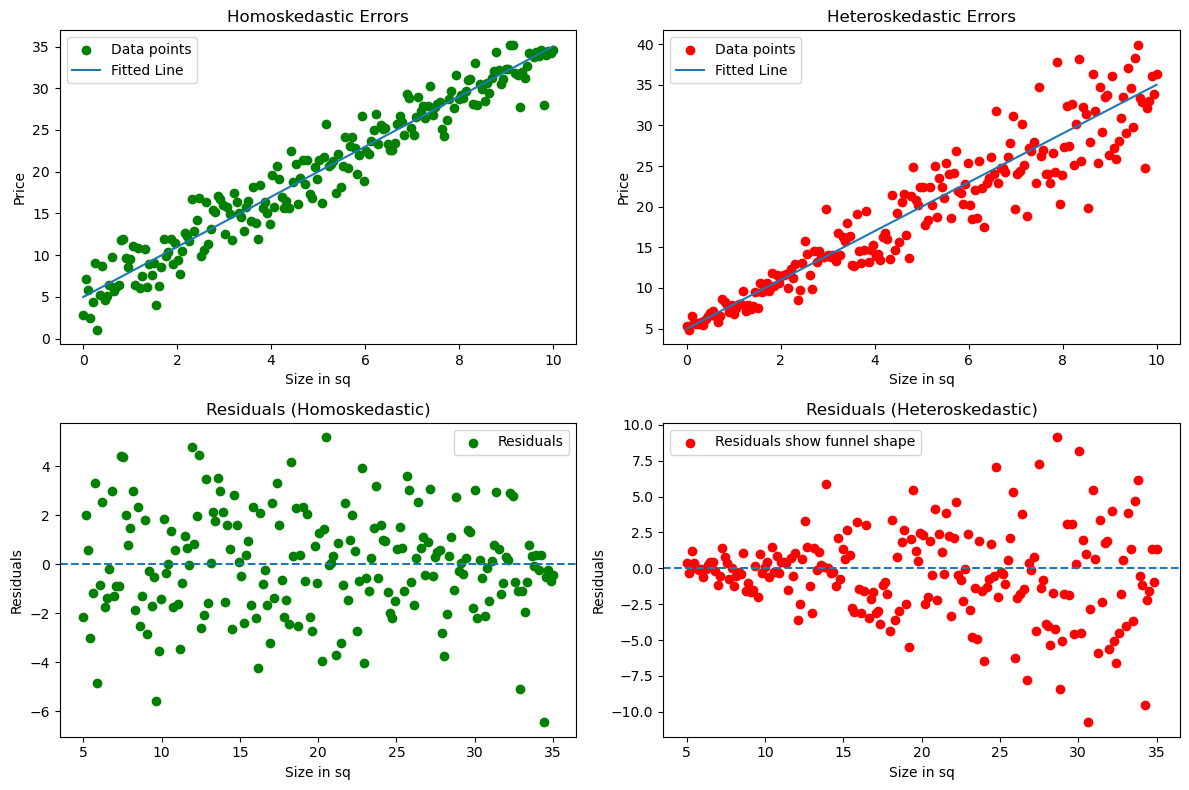

Variance of residuals by size bins (Homoskedastic): [np.float64(5.4399424118748225), np.float64(5.017954845277179), np.float64(5.336130995132632), np.float64(2.881998485442673), np.float64(3.349855160365643)]
Variance of residuals by size bins (Heteroskedastic): [np.float64(0.6852373803839601), np.float64(4.323434440791493), np.float64(7.468415207394403), np.float64(15.123670036514966), np.float64(17.376737976052013)]


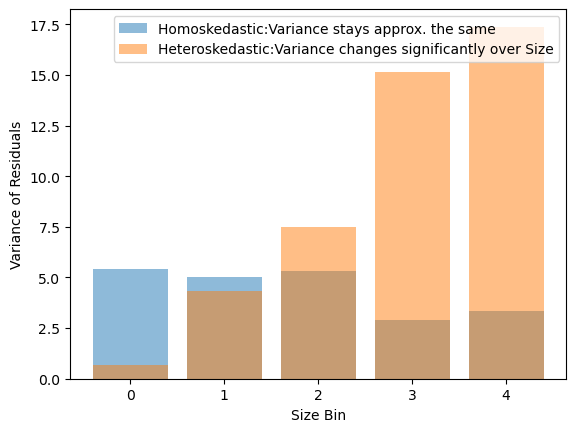

In [5]:
np.random.seed(123) # for reproducibility of random numbers

n = 200 # Number of houses

size = np.linspace(0, 10, n)  # house sizes in sq

beta_0, beta_1 = 5, 3 # True relationship
price_true = beta_0 + beta_1 * size # true relationship between Price and Size

errors_homo = np.random.normal(0, 2, n) # Homoskedastic errors
price_homo = price_true + errors_homo # distorted relationship between Price and Size with homoskedastic errors

errors_hetero = np.random.normal(0, 0.5 + 0.5*size, n)  # Heteroskedastic errors: variance changes with size
price_hetero = price_true + errors_hetero # distorted relationship between Price and Size with heteroskedastic errors



# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Homoskedastic data
axes[0,0].scatter(size, price_homo, color="green", label="Data points")
axes[0,0].plot(size, price_true, label="Fitted Line")
axes[0,0].set_title("Homoskedastic Errors")
axes[0,0].set_ylabel("Price")
axes[0,0].set_xlabel("Size in sq")
axes[0,0].legend()

# Heteroskedastic data
axes[0,1].scatter(size, price_hetero, color="red", label="Data points")
axes[0,1].plot(size, price_true, label="Fitted Line")
axes[0,1].set_title("Heteroskedastic Errors")
axes[0,1].set_ylabel("Price")
axes[0,1].set_xlabel("Size in sq")
axes[0,1].legend()


# Residuals
res_homo = price_homo - price_true 
res_hetero = price_hetero - price_true

# Residuals homoskedastic
axes[1,0].scatter(price_true, res_homo, color="green", label="Residuals")
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals (Homoskedastic)")
axes[1,0].set_ylabel("Residuals")
axes[1,0].set_xlabel("Size in sq")
axes[1,0].legend()

# Residuals heteroskedastic
axes[1,1].scatter(price_true, res_hetero, color="red", label="Residuals show funnel shape")
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Residuals (Heteroskedastic)")
axes[1,1].set_ylabel("Residuals")
axes[1,1].set_xlabel("Size in sq")
axes[1,1].legend()

plt.tight_layout()
plt.show()


bins = 5 # Number of bins
bin_edges = np.linspace(min(size), max(size), bins+1) # array([ 0.,  2.,  4.,  6.,  8., 10.]) for size=np.linspace(0,10,n)
# | Bin | Size Range |
# | --- | ---------- |
# | 1   | 0 – 2      |
# | 2   | 2 – 4      |
# | 3   | 4 – 6      |
# | 4   | 6 – 8      |
# | 5   | 8 – 10     |

#print(list(range(len(bin_edges)-1)))
#print(size)
#print((size >= bin_edges[0]) & (size < bin_edges[0+1]),"\n")
#print((size >= bin_edges[1]) & (size < bin_edges[1+1]),"\n")

def residual_var_by_bin(residuals, size, bin_edges):
    var_list = []
    for i in range(len(bin_edges)-1): # go through every size interval by iterating over [0, 1, 2, 3, 4]
        mask = (size >= bin_edges[i]) & (size < bin_edges[i+1]) # check which house sizes are between the Size Range of Bin i
        var_bin = np.var(residuals[mask]) # np.var(res_homo[mask]) -> computes variance of Residuals of houses in specific Size range
        var_list.append(var_bin) # adds that variance to the list
    return var_list

# Compute variance per bin
var_homo = residual_var_by_bin(res_homo, size, bin_edges)
var_hetero = residual_var_by_bin(res_hetero, size, bin_edges)

print("Variance of residuals by size bins (Homoskedastic):", var_homo)
print("Variance of residuals by size bins (Heteroskedastic):", var_hetero)



plt.bar(range(bins), var_homo, alpha=0.5, label="Homoskedastic:Variance stays approx. the same")
plt.bar(range(bins), var_hetero, alpha=0.5, label="Heteroskedastic:Variance changes significantly over Size")
plt.xlabel("Size Bin")
plt.ylabel("Variance of Residuals")
plt.legend(loc=0)
plt.show()

### Normality of errors


Normality of Errors means that the residuals (errors) of the regression model are normally distributed around zero.

- In other words, most errors are small, and large positive or negative errors are rare, forming a bell-shaped distribution.
- This assumption does not affect the estimates of the coefficients $\hat{\beta_0}$ and $\hat{\beta_1}$ but it is important for statistical inference (e.g., confidence intervals and hypothesis tests).
- It is usually checked using a Q–Q plot or a histogram of residuals.

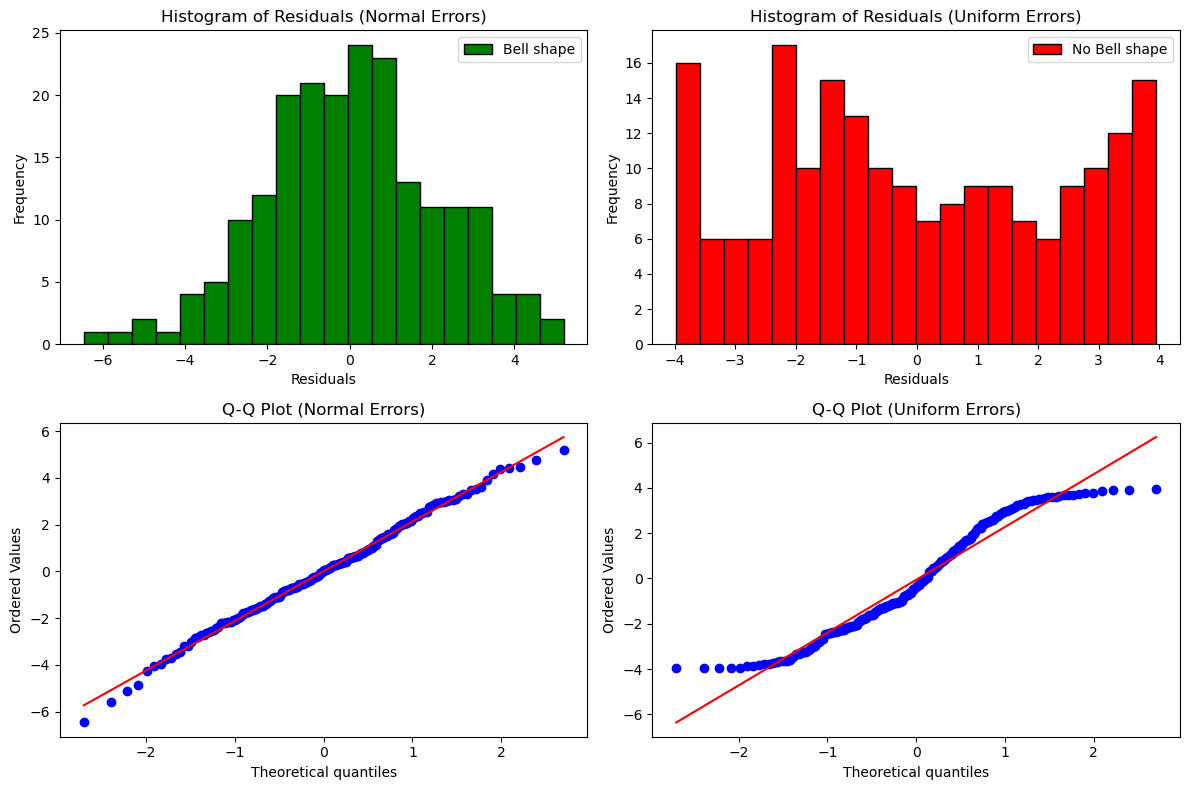

In [6]:
np.random.seed(123)

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in square meters

beta_0, beta_1 = 5, 3 # true coefficients
price_true = beta_0 + beta_1 * size # true relationship between Price and Size


errors_normal = np.random.normal(0, 2, n) # Normal distributed errors
price_normal = price_true + errors_normal # distorted relationship between Price and Size using normal distributed errors

errors_uniform = np.random.uniform(-4, 4, n) # Uniform distributed errors
price_uniform = price_true + errors_uniform # distorted relationship between Price and Size using uniformly distributed errors


# Residuals
res_normal = price_normal - price_true # errors = price - predicted_price
res_uniform = price_uniform - price_true


# Plot
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Histogram (Normal)
axes[0,0].hist(res_normal, bins=20, color="green", edgecolor="black",label="Bell shape")
axes[0,0].set_title("Histogram of Residuals (Normal Errors)")
axes[0,0].set_xlabel("Residuals")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# Histogram (Uniform)
axes[0,1].hist(res_uniform, bins=20, color="red", edgecolor="black",label="No Bell shape")
axes[0,1].set_title("Histogram of Residuals (Uniform Errors)")
axes[0,1].set_xlabel("Residuals")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()


# QQ Plot (Normal)
stats.probplot(res_normal, dist="norm", plot=axes[1,0])
axes[1,0].set_title("Q-Q Plot (Normal Errors)")


# QQ Plot (Uniform)
stats.probplot(res_uniform, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot (Uniform Errors)")


plt.tight_layout()
plt.show()

### No Extreme Outliers

No Extreme Outliers means that there should be no observations that are extremely far from the rest of the data and strongly influence the regression line.

- Such outliers can pull the fitted line toward them, which can distort the estimated coefficients $\hat{\beta_0}$ and $\hat{\beta_1}$.
- They can also affect statistical inference, leading to misleading conclusions.
- This assumption is typically checked using boxplots, scatterplots, or residuals vs. fitted plots to identify unusually large residuals or extreme data points.

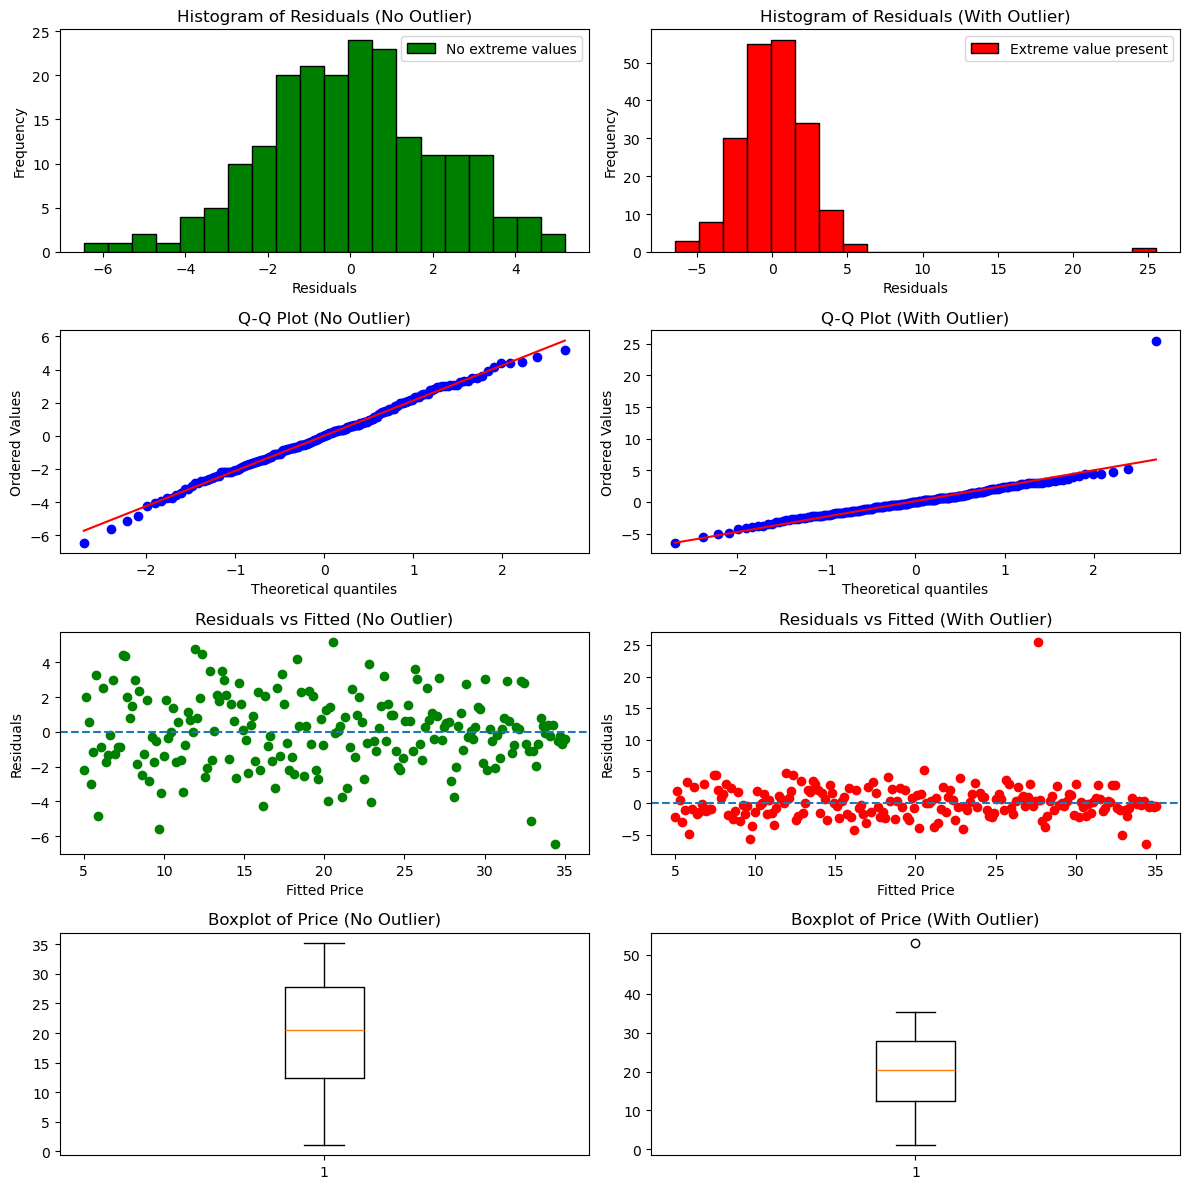

In [7]:
np.random.seed(123) # for reproducibility of random numbers

n = 200 # number of houses

size = np.linspace(0, 10, n) # house sizes in square meters

beta_0, beta_1 = 5, 3 # true coefficients
price_true = beta_0 + beta_1 * size # true relationship between Price and Size


errors_normal = np.random.normal(0, 2, n) # Normal distributed errors
price_normal = price_true + errors_normal # distorted relationship between Price and Size


# Create dataset with an extreme outlier
price_outlier = price_normal.copy()
price_outlier[150] += 25 # add outlier at position 150 and add 25 on top of it


# Residuals
res_normal = price_normal - price_true
res_outlier = price_outlier - price_true


# Plot
fig, axes = plt.subplots(4, 2, figsize=(12,12))



# Histograms
axes[0,0].hist(res_normal, bins=20, color="green", edgecolor="black", label="No extreme values")
axes[0,0].set_title("Histogram of Residuals (No Outlier)")
axes[0,0].set_xlabel("Residuals")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

axes[0,1].hist(res_outlier, bins=20, color="red", edgecolor="black", label="Extreme value present")
axes[0,1].set_title("Histogram of Residuals (With Outlier)")
axes[0,1].set_xlabel("Residuals")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()


# Q-Q plots
stats.probplot(res_normal, dist="norm", plot=axes[1,0])
axes[1,0].set_title("Q-Q Plot (No Outlier)")

stats.probplot(res_outlier, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot (With Outlier)")



# Residuals vs Fitted
axes[2,0].scatter(price_true, res_normal, color="green")
axes[2,0].axhline(0, linestyle="--")
axes[2,0].set_title("Residuals vs Fitted (No Outlier)")
axes[2,0].set_xlabel("Fitted Price")
axes[2,0].set_ylabel("Residuals")

axes[2,1].scatter(price_true, res_outlier, color="red")
axes[2,1].axhline(0, linestyle="--")
axes[2,1].set_title("Residuals vs Fitted (With Outlier)")
axes[2,1].set_xlabel("Fitted Price")
axes[2,1].set_ylabel("Residuals")

axes[3,0].boxplot(price_normal)
axes[3,0].set_title("Boxplot of Price (No Outlier)")

axes[3,1].boxplot(price_outlier)
axes[3,1].set_title("Boxplot of Price (With Outlier)")


plt.tight_layout()
plt.show()

<a class="anchor" id="min"></a>
## 3. Core Minimization problem (Ordinary Least Squares)

#### Model

The simple linear regression model is

$$
\text{Price}_i = \beta_0 + \beta_1 \cdot \text{Size}_i + \varepsilon_i \hspace{2 mm} \text{ for each house }i \text{ and } \varepsilon_i \sim \mathcal{N}(0,\sigma^2)
$$

and the predited value using the estimates $\hat{\beta_0}$ and $\hat{\beta_1}$ for $\beta_0$ and $\beta_0$ is

$$
\widehat{\text{Price}_i} = \hat{\beta_0} + \hat{\beta_1} \cdot \text{Size}_i 
$$

#### Residuals

The residual is the difference between observed and predicted value:

$$
\begin{align}
\varepsilon_i &= \text{Price}_i - \widehat{\text{Price}_i} \\
\Leftrightarrow \varepsilon_i &= \text{Price}_i - (\hat{\beta_0} + \hat{\beta_1} \cdot \text{Size}_i) \\
\Leftrightarrow \varepsilon_i &= \text{Price}_i - \hat{\beta_0} - \hat{\beta_1} \cdot \text{Size}_i
\end{align}
$$


#### Ordinary Least squares (OLS)

Simple linear regression estimates $\beta_0$ and $\beta_1$ by solving

$$
\min_{\beta_0,\beta_1} \sum_{i=1}^n \varepsilon_i^2 = \min_{\beta_0,\beta_1} \sum_{i=1}^n (\text{Price}_i - \hat{\beta_0} - \hat{\beta_1} \cdot \text{Size}_i)^2  
$$

or in matrix form


$$
\min_{\beta} (\text{Price} - X\beta)^\top (\text{Price} - X\beta)
$$

This means:

- Compute the squared difference between actual Price of a house denoted as $\text{Price}_i$ and the predicted Price denoted as $\widehat{\text{Price}_i}$
- Sum these squared errors over all $n$ houses.
- Choose $\beta_0$ and $\beta_1$ that make this sum as small as possible and label them as $\hat{\beta_0}$ and $\hat{\beta_1}$.

Note: The Objective Function $\sum_{i=1}^n (\text{Price}_i - \hat{\beta_0} - \hat{\beta_1} \cdot \text{Size}_i)^2$ is called **Sum of squared errors** or short **SSE**


#### Resulting OLS Estimates

Solving the minimization yields:

$$
\hat{\beta_1} = \frac{\sum_{i=1}^n (\text{Size}_i - \overline{\text{Size}})(\text{Price}_i - \overline{\text{Price}})}{\sum_{i=1}^n (\text{Size}_i - \overline{\text{Size}})^2} 

\\[5mm]
\hat{\beta_0} =  \overline{\text{Price}} - \hat{\beta_1} \cdot \overline{\text{Size}}
$$

- $\overline{\text{Size}}$ is the mean of all values for the independent variable **Size**
- $\overline{\text{Price}}$ is the mean of all values for the dependent variable **Price**

or in matrix notation

$$
\hat{\beta} = \begin{pmatrix} \hat{\beta_0} \\ \hat{\beta_1} \end{pmatrix} = (X^\top X)^{-1} X^\top \text{Price} = \underbrace{\begin{pmatrix} n & \sum_{i=1}^n \text{Size}_i \\ \sum_{i=1}^n \text{Size}_i & \sum_{i=1}^n \text{Size}_i^2 \end{pmatrix}^{-1}}_{(X^\top X)^{-1}} \underbrace{\begin{pmatrix} \sum_{i=1}^n \text{Price}_i \\ \sum_{i=1}^n \text{Price}_i \cdot \text{Size}_i \end{pmatrix}}_{X^\top \text{Price}}
$$

&#128204; Simple linear regression finds the line that minimizes the sum of squared residuals between observed and predicted values.

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression() # model is now a LinearRegression object
model = LinearRegression(fit_intercept=False) # # model is a LinearRegression object where the Regression matrix has no intercept column

model.fit(X, y) # X of shape (number_observations,number_features) and y of shape (number_observations,) and model is now a a fitted LinearRegression object

model.n_features_in_ # Number of features
model.coef_ # get estimated slopes beta_1_hat,...,beta_p_hat of shape (n_features_in_,) as numpy.ndarray
model.intercept_ # get estimated intercept beta_0_hat
model.feature_names_in_ # Feature names (if using pandas)
model.rank_ # Rank of X matrix
model.singular_ # Singular values
model.predict(X_new) # Predict new values
model.score(X, y) # R^2 score (more on this later)
model.get_params() # Get parameters
# {
#  'copy_X': True,
#  'fit_intercept': True,
#  'n_jobs': None,
#  'positive': False,
#  'tol': 1e-06
# }

```

In [8]:
from sklearn.linear_model import LinearRegression # Import LinearRegression libraries from sklearn 

Real intercept 3 and slope 2 compared to estimated intercept -8.221271416202683 and estimated slope 2.013342737102346
The size variable has shape (100,) wich is one diemensional but LinearRegression.fit() requires 2 dimensions as (100, 1)
Manually estimated intercept -8.22 and slope 2.01 compared to model estimates of intercept -8.22 and slope 2.01
First 3 manually made predictions [158.88617576 191.09965956 277.67339725] compared to model predictions [158.88617576 191.09965956 277.67339725]


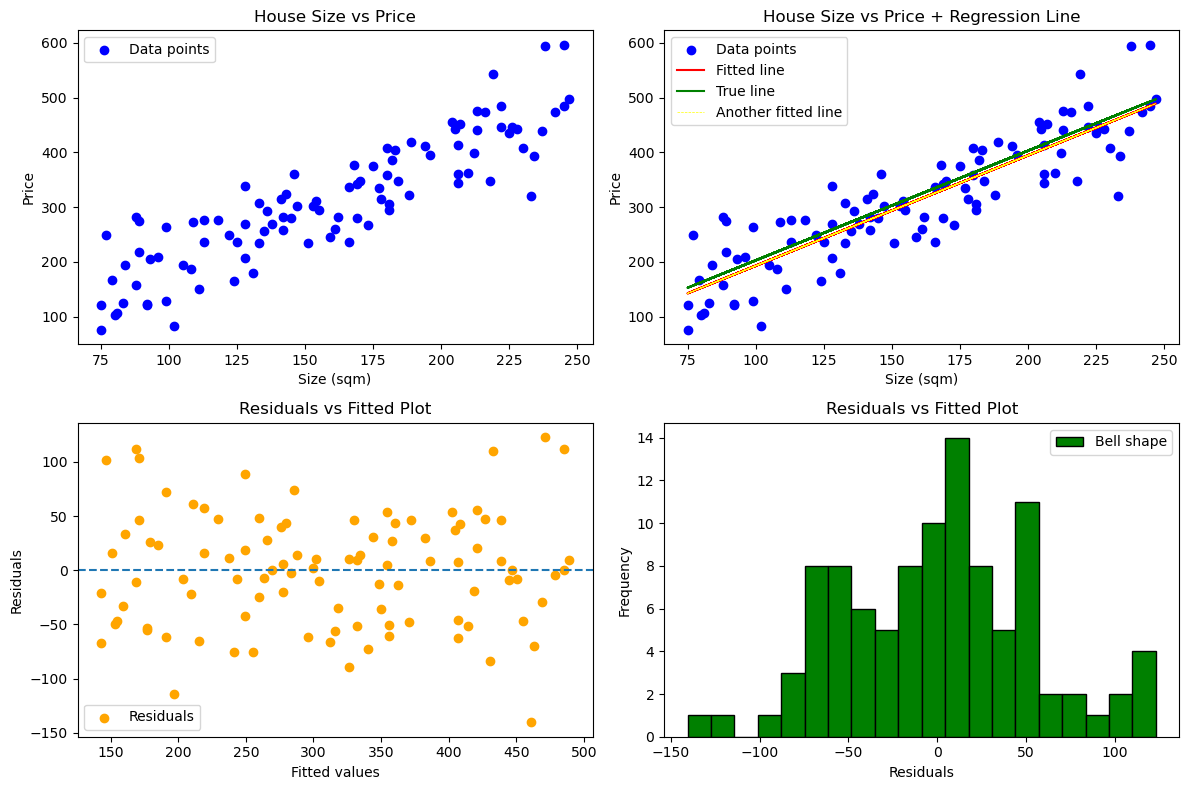

In [9]:
# Generate data according to assumptions

np.random.seed(100) # for reproducibility of random numbers

n = 100 # number of houses

size = np.random.randint(75,250,n) # house sizes in square meters

beta_0, beta_1 = 3, 2 # true coefficients

true_price = beta_0 + beta_1 * size # true relationship between Price and Size

errors = np.random.normal(loc=0,scale=50,size=n) # normally distributed and independent errors

price = true_price + errors # distorted and linear relationship between Price and Size

# Plot data
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,8))
axes[0,0].scatter(size, price, color='blue', label='Data points')
axes[0,0].set_title("House Size vs Price")
axes[0,0].set_xlabel("Size (sqm)")
axes[0,0].set_ylabel("Price")
axes[0,0].legend()

# Train model manually
mean_size, mean_price = np.mean(size), np.mean(price) # compute mean of Sizes and Prices
numerator = np.sum((size - mean_size)*(price - mean_price)) 
denominator = np.sum((size - mean_size)**2)
beta_1_hat = numerator / denominator # estimate slop
beta_0_hat = mean_price - beta_1_hat * mean_size # estimate intercept
print(f"Real intercept {beta_0} and slope {beta_1} compared to estimated intercept {beta_0_hat} and estimated slope {beta_1_hat}")
price_hat = beta_0_hat + beta_1_hat * size # make predictions for already seen houses
residuals = price - price_hat # errors = y - y_hat


# Plot Regression line
axes[0,1].scatter(size, price, color='blue', label='Data points')
axes[0,1].plot(size,price_hat,color="red",label="Fitted line")
axes[0,1].plot(size,true_price,color="green",label="True line")
axes[0,1].set_title("House Size vs Price + Regression Line")
axes[0,1].set_xlabel("Size (sqm)")
axes[0,1].set_ylabel("Price")
axes[0,1].legend()

# Residuals vs Fitted Plot
axes[1,0].scatter(price_hat, residuals, color='orange', label='Residuals')
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Residuals vs Fitted Plot")
axes[1,0].set_xlabel("Fitted values")
axes[1,0].set_ylabel("Residuals")
axes[1,0].legend()


# Histogram of Residuals
axes[1,1].hist(residuals, bins=20, color="green", edgecolor="black",label="Bell shape")
axes[1,1].set_title("Residuals vs Fitted Plot")
axes[1,1].set_xlabel("Residuals")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()


# Train model via LinearRegression library and compare
print(f"The size variable has shape {size.shape} wich is one diemensional but LinearRegression.fit() requires 2 dimensions as {size.reshape(-1,1).shape}")
X = size.reshape(-1,1) # reshape size into having 100 rows and 1 column
model = LinearRegression().fit(X, price) # train the model
print(f"Manually estimated intercept {beta_0_hat:.2f} and slope {beta_1_hat:.2f} compared to model estimates of intercept {model.intercept_:.2f} and slope {model.coef_[0]:.2f}")
print(f"First 3 manually made predictions {price_hat[0:3]} compared to model predictions {model.predict(X)[0:3]}")

axes[0,1].plot(size,model.predict(X),color="yellow",label="Another fitted line",linewidth=0.5,linestyle='dashed')
axes[0,1].legend()

plt.tight_layout()
plt.show()

### L1 loss vs L2 loss


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
border:2px solid white;
width:50%;
">


<h5 style="text-align:center;">L1 loss</h5>

$$
\sum_{i=1}^n \mid y_i - \hat{y}_i \mid
$$

**Motivation:** &#128300; Strongly penalize large errors


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
border:2px solid white;
width:50%;
">

<h5 style="text-align:center;">L2 loss</h5>

**Motivation:** 🛡️ Robust to outliers

&#128202;
</div>

</div>

<a class="anchor" id="quality"></a>
## 4. Model Quality

In Ordinary Least Squares (OLS), the model parameters are estimated by minimizing the **Sum of Squared Errors (SSE)**, which measures the squared difference between observed and predicted values.

$$
SSE = \sum_{i=1}^n \hat{\varepsilon_i}^2 = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

To evaluate model quality, two additional quantities are used. The **Total Sum of Squares (SST)** measures the total variation of the data around the mean:

$$
SST = \sum_{i=1}^{n}(y_i - \bar{y})^2
$$

The **Regression Sum of Squares (SSR)** measures the variation explained by the model:

$$
SSR = \sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2
$$

These quantities satisfy the relationship:

$$
SST = SSE + SSR \Leftrightarrow \sum_{i=1}^{n}(y_i - \bar{y})^2 = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2
$$

A common measure of model quality is the **coefficient of determination**:

$$
R^2 = \frac{SSR}{SST} = \frac{\text{Variation explained by the model}}{\text{Total variation of the data}}
$$

The value of $R^2$ lies between **0 and 1** and represents the proportion of variance explained by the model, which makes it useful for comparing different regression models.

Note: The target variable $\text{Price}$ is denoted here as $y$ and  $\widehat{\text{Price}}$ is replaced with $\hat{y}$.


Is SST = SSE + SSR ?: True
Manually estimated intercept 32.035 and slope 7.358 compared to model intercept 32.035 and slope 7.358
Manually computed score R^2 is 0.703 and model score R^2 is 0.703


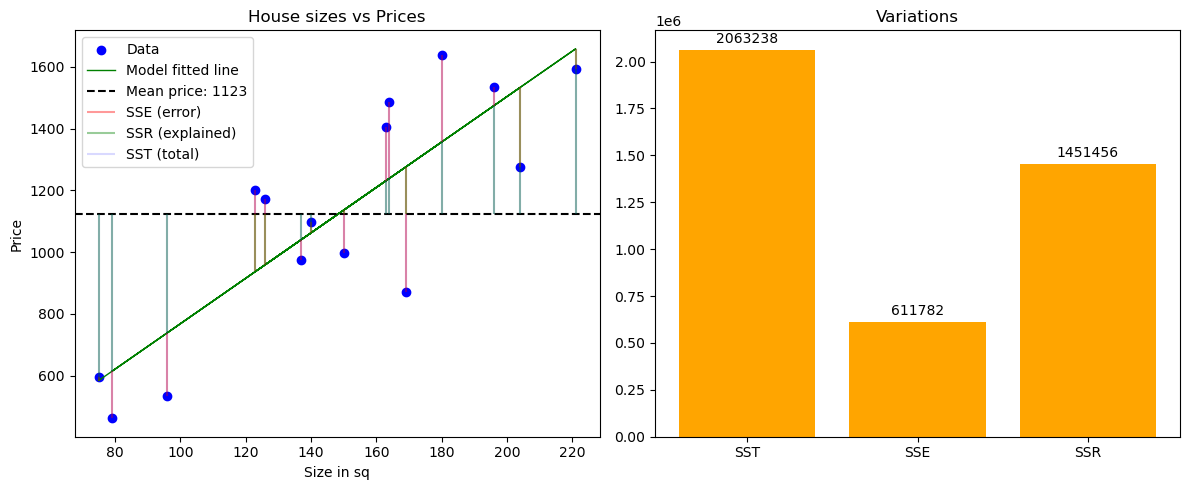

In [10]:
np.random.seed(185) # for reproducibility of random numbers

# Generte data
n = 15 # number of houses
size = np.random.randint(75,250,n) # house sizes between 75 and 250 square meters
beta_0, beta_1 = 5, 7 # ture coefficients
true_price = beta_0 + beta_1 * size # true linear relationship between Price and Size
error = np.random.normal(loc=0,scale=230,size=n) # independent and normal distributed errors around 0 with constant variance
price = true_price + error # distorted relationship between Price and Size


# Fit Model manually
mean_size, mean_price = np.mean(size), np.mean(price) # compute mean of Sizes and Prices
numerator = np.sum((size - mean_size)*(price - mean_price)) 
denominator = np.sum((size - mean_size)**2)
beta_1_hat = numerator / denominator # estimate slop
beta_0_hat = mean_price - beta_1_hat * mean_size # estimate intercept
price_hat = beta_0_hat + beta_1_hat * size # make predictions for already seen houses
residuals = price - price_hat # errors = y - y_hat
SST = np.sum((price - mean_price)**2) # Sum of squares total
SSE = np.sum(residuals**2) # Sum of squared errors
SSR = np.sum((price_hat - mean_price)**2) # Regression Sum of squares
print(f"Is SST = SSE + SSR ?: {round(SST) == round(SSE) + round(SSR)}")
R2 = SSR / SST 


# Fit manually with LinearRegression()
model = LinearRegression() # Setup LinearRegression() object
X = size.reshape(-1,1) # turn size into 2D matrix
model.fit(X,price) # Train model


# Compare results
print(f"Manually estimated intercept {beta_0_hat:.3f} and slope {beta_1_hat:.3f} compared to model intercept {model.intercept_:.3f} and slope {model.coef_[0]:.3f}")
print(f"Manually computed score R^2 is {R2:.3f} and model score R^2 is {model.score(X,price):.3f}")


# Plotting
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(12,5))

axes[0].scatter(size,price,color="blue",label="Data")
#axes[0].plot(size,price_hat,color="red",label="Manualy fitted line")
axes[0].plot(size,model.predict(X),color="green",label="Model fitted line",linewidth=1)
axes[0].axhline(mean_price, linestyle="--",color="black",label=f"Mean price: {round(mean_price)}")

for i in range(n):

    # SSE: data point to regression line
    axes[0].vlines(
        size[i], price_hat[i], price[i],
        colors="red", alpha=0.4,
        label="SSE (error)" if i == 0 else ""
    )

    # SSR: regression line to mean
    axes[0].vlines(
        size[i], mean_price, price_hat[i],
        colors="green", alpha=0.4,
        label="SSR (explained)" if i == 0 else ""
    )

    # SST: data point to mean
    axes[0].vlines(
        size[i], mean_price, price[i],
        colors="blue", alpha=0.15,
        label="SST (total)" if i == 0 else ""
    )


axes[0].set_xlabel("Size in sq")
axes[0].set_ylabel("Price")
axes[0].set_title("House sizes vs Prices")
axes[0].legend()

bars = axes[1].bar(range(3), [SST, SSE, SSR], tick_label=['SST', 'SSE', 'SSR'],color="orange")
bars
axes[1].bar_label(bars, fmt="%.0f", padding=3)
axes[1].set_title("Variations")

plt.tight_layout()
plt.show()

<a class="anchor" id="stats"></a>
## 5. Statistical Inference

In Simple Linear Regression, statistical inference is used to draw conclusions about the population relationship between 
$X$ (aka *Size*) and $Y$ (aka *Price*) based on the sample data.

The main statistical inference methods are listed as follows:


| Method                                | Purpose                               |
| ------------------------------------- | ------------------------------------- |
| t-test/F-test for $\beta_1$                  | Test if $X$ significantly affects $Y$ |
| t-test/F-test for $\beta_0$                  | Test intercept significance           |
| Confidence intervals                  | Estimate plausible parameter values for $\beta_0$ and $\beta_1$   |



#### t-Test for the Regression Coefficients


Used to test whether the intercept $\beta_0$ or slope $\beta_1$ is significantly different from some value $b$ often 0


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Hypotheses (for intercept)</u></h5>

$$
H_0: \beta_0 = b \text{ vs. } H_1: \beta_0 \neq b 
$$

This kind of Hypothesis is called two-sided test since $\beta_0 \neq b$ means $\beta_0$ can be smaller or bigger than $b$

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Hypotheses (for slope)</u></h5>

$$
H_0: \beta_1 = b \text{ vs. } H_1: \beta_1 \neq b 
$$

This kind of Hypothesis is called two-sided test since $\beta_1 \neq b$ means $\beta_1$ can be smaller or bigger than $b$


</div>

</div>

Note: $H_0$ and $H_1$ are called Nullhypothesis and Alternativhypothesis

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Test Statistic (for intercept)</u></h5>

$$
t_0 = \frac{\hat{\beta_0} - b}{\sqrt{\mathrm{Var}(\hat{\beta_0})}} \\
$$

$$
\mathrm{Var}(\hat{\beta_0}) = \left(\frac{1}{n}  +\frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}\right) \mathrm{Var}(\text{SSE})
$$



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Test Statistic (for slope)</u></h5>


$$
t_1 = \frac{\hat{\beta_1} - b}{\sqrt{\mathrm{Var}(\hat{\beta_1})}}
$$

$$
\mathrm{Var}(\hat{\beta_1}) = \frac{1}{\sum_{i=1}^n (x_i - \bar{x})^2} \mathrm{Var}(\text{SSE})
$$


</div>

</div>

$$
\mathrm{Var}(\text{SSE}) = \frac{1}{n-2} \text{SSE}  = \frac{1}{ \underbrace{{n-2}}_{=: \text{df}}} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Bonus:**

$$
\mathrm{Cov}(\hat{\beta}) = 
\begin{pmatrix} 
\mathrm{Var}(\hat{\beta_0}) & \mathrm{Cov}(\hat{\beta_0},\hat{\beta_1}) \\
\mathrm{Cov}(\hat{\beta_0},\hat{\beta_1}) & \mathrm{Var}(\hat{\beta_1}) \\
\end{pmatrix} = \mathrm{Var}(\text{SSE})(X^{\top} X)^{-1}
$$

with 

$$
\mathrm{Cov}(\hat{\beta_0},\hat{\beta_1}) = -\frac{\bar{x}}{\sum_{i=1}^n (x_i - \bar{x})^2} \mathrm{Var}(\text{SSE}) \text{ and }
X^{\top}X = \begin{pmatrix} n & \sum_{i=1}^n x_i \\ \sum_{i=1}^n x_i & \sum_{i=1}^n x_i^2 \end{pmatrix}
$$

We divide by $n-2$ ($n$ is number of observations / houses) which are the so called **degrees of freedom** or short $\text{df}$. When estimating $\text{SSE}$, we lose degrees of freedom because the simple regression model estimates two parameters $\beta_0$ and $\beta_1$ from the data. Therefore, from the 
$n$ observations, 2 degrees of freedom are used, leaving $n-2$ degrees of freedom.


##### Distribution of $t_{0,1}$

>To decide whether to reject the null hypotheses $H_0:\beta_0 = b$ or $H_0:\beta_1 = b$, we need to know which values of the t-test statistics are expected if the true coefficients are actually equal to $b$. Imagine we repeatedly collect many datasets of house sizes and prices where the true coefficient (either the intercept $\beta_0$ or the slope $beta_1$) is $b$. For each dataset we fit a regression model and compute the corresponding t-statistic $t_0$ or $t_1$. Because the data contain random noise, the estimated coefficients $\beta_0$ and $\beta_1$ and their corresponding t-statistics will vary from sample to sample. If we plot these t-statistic values, they follow a specific distribution called the Student’s t-distribution with $n-2$ degrees of freedom.
For a new dataset we compute its test statistic ($t_0$ or $t_1$) and compare it to this distribution. If the value lies too far in the tails beyond a threshold determined by the significance level $\alpha$,the result is unlikely under $H_0$, and we reject the null hypothesis.
The significance level $\alpha$ is a number between 0 and 1 (often 0.05) that represents the maximum probability of observing a t-statistic this extreme if the null hypothesis were true. However $\alpha$ is actually just the red area in the following picture.
In a two-sided test, the probability mass $\alpha$ is split between the two tails of the Student t-distribution, so each tail contains an area of $\frac{\alpha}{2}$.

<p align="center">
<img src="two_sided.jpg" width="400"/>
</p>


>This defines two critical values (short CV) that mark the boundaries of the rejection region. If the computed $t_0$ or $t_1$ falls beyond these boundaries, the area between the observed value and the corresponding tail of the Student's t-distribution is smaller than $\alpha$.In that case, the observed statistic would be very unlikely under $H_0$, and we reject the null hypothesis. If the value lies inside the central region of the distribution, we do not reject $H_0$.



```python
import statsmodels.api as sm # for Statistical Inference

X = sm.add_constant(feature) # adds intercept column to 1 dimensional feature
model = sm.OLS(target, X).fit() # fit model
model.summary() # Get a full regression summary (coefficients,standard errors,t-statistics,p-values,confidence intervals,R2 and adjusted R2, F-statistic, Durbin–Watson statistic,information criteria (AIC/BIC))

# Perform hypothesis tests
model.t_test("feature = 0") # test if slope equals zero
model.f_test("feature = 0") # test if slope equals zero

model.conf_int() # confidence intervals for coefficients

model.predict(X_new) # predictions for new data 
model.predict([[1,150]]) # prediction for single new observation 

sm.stats.durbin_watson(model.resid) # Durbin–Watson test (autocorrelation/independence of errors)
sm.stats.jarque_bera(model.resid) # Jarque–Bera test (normality of errors)

model.cov_params() # covariance matrix of coefficients
```

Fit many other models

| Model         | Purpose                   |
| ------------- | ------------------------- |
| `sm.OLS()`    | linear regression         |
| `sm.Logit()`  | logistic regression       |
| `sm.Probit()` | probit model              |
| `sm.GLM()`    | generalized linear models |
| `sm.WLS()`    | weighted least squares    |
| `sm.RLM()`    | robust regression         |



Access individual statistics instead of printing the summary

| Attribute            | Meaning                |
| -------------------- | ---------------------- |
| `model.params`       | estimated coefficients |
| `model.bse`          | standard errors        |
| `model.tvalues`      | t-statistics           |
| `model.pvalues`      | p-values               |
| `model.rsquared`     | $R^2$                 |
| `model.rsquared_adj` | adjusted $R^2$        |
| `model.fvalue`       | F-statistic            |
| `model.f_pvalue`     | F-test p-value         |
| `model.resid`        | residuals              |
| `model.fittedvalues` | predicted values       |



In [11]:
from scipy.stats import t # for Students t distribtuion

In [12]:
def simulate_t0_distribution(ax,size, b0, slope, n_sim=5000,alpha=0.05):

    n = len(size) # extract the number of observations / houses
    t0_values = [] # list for values of t_0

    for _ in range(n_sim):

        error = np.random.normal(0,600,n) # per iteration always get  different errors
        price = b0 + slope * size + error 

        # Calculate t_0
        mean_price = np.mean(price)
        mean_size = np.mean(size)

        num = np.sum((size-mean_size)*(price-mean_price))
        denom = np.sum((size-mean_size)**2)

        beta1_hat = num/denom
        beta0_hat = mean_price - beta1_hat*mean_size

        price_hat = beta0_hat + beta1_hat*size
        residuals = price - price_hat

        SSE = np.sum(residuals**2)
        sigma2 = SSE/(n-2)

        Var_beta0_hat = sigma2*(1/n + (mean_size**2)/np.sum((size-mean_size)**2))

        t0 = (beta0_hat - b0)/np.sqrt(Var_beta0_hat) # compute t_0

        t0_values.append(t0) # add t_0 to list 

    x = np.linspace(-5,5,400) # for plotting the Student t distribution
    
    # get rid of ax in parameterlist
    #plt.figure(figsize=(8,5))
    #plt.hist(t0_values,bins=50,density=True,alpha=0.6,label="Simulated $t_0$")
    #plt.plot(x,t.pdf(x,df=n-2),linewidth=2,label="Student t (df=n-2)")
    #plt.title("Distribution of $t_0$")
    #plt.legend()

    #return plt.show()

    ax.hist(t0_values,bins=50,density=True,alpha=0.6,label="Simulated $t_0$") # histogram of t_0 values with their frequencies 
    ax.plot(x,t.pdf(x,df=n-2),linewidth=2,label="Student t (df=n-2)")
    tcrit = t.ppf(1 - alpha/2, df=n-2) # Critical values
    ax.axvline(tcrit, color="red", linestyle="--", label="Critical value") # Critical value on right tail
    ax.axvline(-tcrit, color="red", linestyle="--") # Critical value on left tail
    ax.set_title("Distribution of $t_0$")
    ax.legend()

    

def simulate_t1_distribution(ax,size, intercept, b1, n_sim=5000,alpha=0.05):

    n = len(size) # extract the number of observations / houses
    t1_values = [] # list for values of t_1

    for _ in range(n_sim):

        error = np.random.normal(0,600,n)
        price = intercept + b1 * size + error

        mean_price = np.mean(price)
        mean_size = np.mean(size)

        num = np.sum((size-mean_size)*(price-mean_price))
        denom = np.sum((size-mean_size)**2)

        beta1_hat = num/denom
        beta0_hat = mean_price - beta1_hat*mean_size

        price_hat = beta0_hat + beta1_hat*size
        residuals = price - price_hat

        SSE = np.sum(residuals**2)
        sigma2 = SSE/(n-2)

        Var_beta1_hat = sigma2 / np.sum((size-mean_size)**2)

        t1 = (beta1_hat - b1)/np.sqrt(Var_beta1_hat) # compute t_1

        t1_values.append(t1) # add t_1 to list 

    x = np.linspace(-5,5,400) # for plotting the Student t distribution

    # get rid of ax in parameterlist
    #plt.figure(figsize=(8,5))
    #plt.hist(t1_values,bins=50,density=True,alpha=0.6,label="Simulated $t_1$")
    #plt.plot(x,t.pdf(x,df=n-2),linewidth=2,label="Student t (df=n-2)")
    #plt.title("Distribution of $t_1$")
    #plt.legend()
    #return plt.show()

    ax.hist(t1_values,bins=50,density=True,alpha=0.6,label="Simulated $t_1$") # histogram of t_0 values with their frequencies
    ax.plot(x,t.pdf(x,df=n-2),linewidth=2,label="Student t (df=n-2)")
    tcrit = t.ppf(1 - alpha/2, df=n-2) # Critical values
    ax.axvline(tcrit, color="red", linestyle="--", label="Critical value") # Critical value on right tail
    ax.axvline(-tcrit, color="red", linestyle="--") # Critical value on leftt tail
    ax.set_title("Distribution of $t_1$")
    ax.legend()

    

Regression matrix  X= 
 [[  1. 111.]
 [  1. 177.]
 [  1. 190.]
 [  1. 143.]
 [  1. 187.]]

Manually estimated intercept -132.1710 and slope 0.4769 compared to model intercept -132.1710 and slope 0.4769
Compare estimated R^2 = 0.0011 with model score R^2 = 0.001148


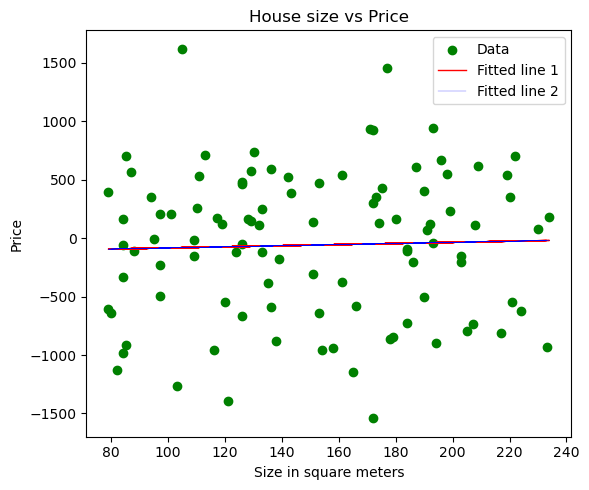

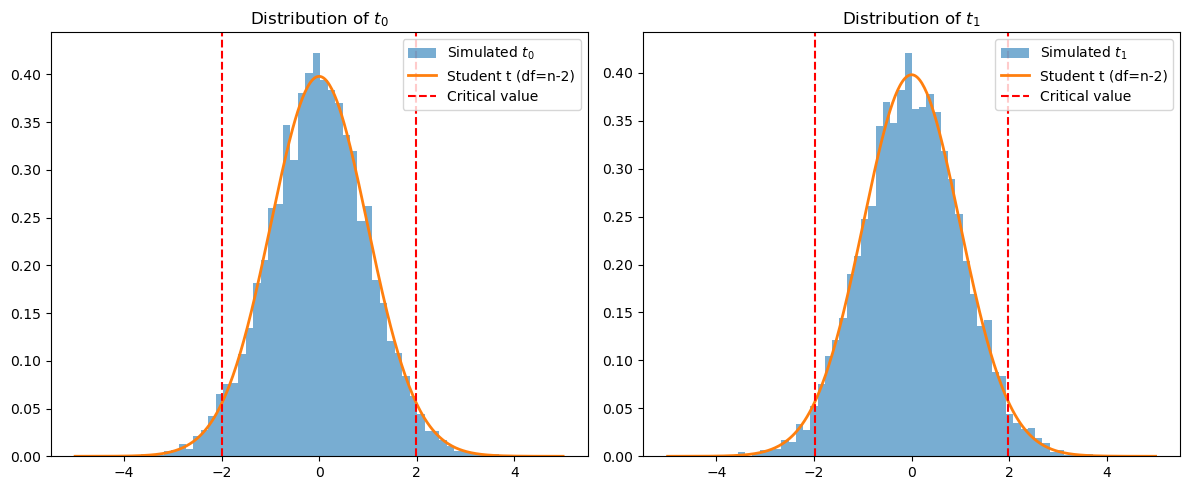

Manually computed Covariance matrix:
[[ 4.97479195e+04 -3.04115327e+02]
 [-3.04115327e+02  2.01962629e+00]]
 and model covariance matrix:
[[ 4.97479195e+04 -3.04115327e+02]
 [-3.04115327e+02  2.01962629e+00]]

Covariance matrix has on diagonal Var_beta_0_hat=49747.920 and Var_beta_1_hat=2.020 and Cov(beta_0_hat,beta_1_hat)=-304.115

Compare t_0=-0.5926 and t_1=0.3356 with model t_0=-0.5926 and t_1=0.3356

Manual Standard Errors
223.0424, 1.4211
Statsmodels Standard Errors
[223.04241642   1.42113556]

Manual p-values
P>|t0| = 0.554825 and P>|t1| = 0.737905 compared to models: [0.55482548 0.7379053 ]

Not reject H_0:b0 = 0 meaning Intercept is not significant
Not reject H_0:b1 = 0 meaning Size does not explain Price
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares  

In [13]:
np.random.seed(1612) # for reproducibility of random numbers

# Generate data
n = 100 # number of houses
size = np.random.randint(75,240,n) # house sizes between 75 and 240 square meters
b0 = 0 # hypothesized value for beta_0
b1 = 0 # hypothesized value for beta_1
beta_0, beta_1 = (b0 + np.random.uniform(-0.5,0.5,1)), (b1 + np.random.normal(loc=2*b1,scale=1,size=1)) # true intercept close to b0 but true slope is not close to b1
error = np.random.normal(loc=0,scale=600,size=n) # independent normal distributed errors around 0
true_price = beta_0 + beta_1 * size # true relationship between Price and Size
price = true_price + error # distorted relationship between Price and Size

# Fit model
mean_price, mean_size = np.mean(price), np.mean(size)
num = np.sum((size - mean_size)*(price - mean_price))
denom = np.sum((size - mean_size)**2)
beta_1_hat = num / denom
beta_0_hat = mean_price - beta_1_hat * mean_size
X = np.column_stack((np.ones(n), size)) # reconfigure size into a matrix with column for intercept and column for size 
print(f"Regression matrix  X= \n {X[0:5,]}\n")
model = LinearRegression().fit(X,price)
print(f"Manually estimated intercept {beta_0_hat:.4f} and slope {beta_1_hat:.4f} compared to model intercept {model.intercept_:.4f} and slope {model.coef_[1]:.4f}")


# Make predictions and compute SSE as well as R2
price_hat = beta_0_hat + beta_1_hat * size
error_hat = price - price_hat
SSE = np.sum(error_hat**2)
SST = np.sum((price - mean_price)**2)
SSR = np.sum((price_hat - mean_price)**2)
R2 = SSR / SST
print(f"Compare estimated R^2 = {R2:.4f} with model score R^2 = {model.score(X,price):4f}")


# Plot
plt.figure(figsize=(6,5))
plt.scatter(size,price,color="green",label="Data")
plt.plot(size,price_hat,color="red",linewidth=1,label="Fitted line 1")
plt.plot(size,model.predict(X),color="blue",linewidth=0.2,label="Fitted line 2")
plt.title("House size vs Price")
plt.xlabel("Size in square meters")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()



# Calculate Var(SSE), Var(beta_0_hat), Var(beta_1_hat), t_0 and t_1
df = n-2
Var_SSE = SSE / df
Var_beta_0_hat = Var_SSE * (1/n + (mean_size**2) / np.sum((size - mean_size)**2))
Var_beta_1_hat = Var_SSE / np.sum((size - mean_size)**2)
t_0 = (beta_0_hat - b0) / np.sqrt(Var_beta_0_hat)
t_1 = (beta_1_hat - b1) / np.sqrt(Var_beta_1_hat)


# Sample distribution of t-test statistic values for t_0 and t_1 seperately
fig, axes = plt.subplots(1,2,figsize=(12,5))

simulate_t0_distribution(axes[0], size, b0, slope=10)
simulate_t1_distribution(axes[1], size, intercept=4, b1=b1)

plt.tight_layout()
plt.show()

model = sm.OLS(price, X).fit()
print(f"Manually computed Covariance matrix:\n{np.linalg.inv(np.dot(X.T,X)) * Var_SSE}\n and model covariance matrix:\n{model.cov_params()}\n")
Cov_b0_b1 = - Var_SSE*mean_size / np.sum((size - mean_size)**2)
print(f"Covariance matrix has on diagonal Var_beta_0_hat={Var_beta_0_hat:.3f} and Var_beta_1_hat={Var_beta_1_hat:.3f} and Cov(beta_0_hat,beta_1_hat)={Cov_b0_b1:.3f}\n")

print(f"Compare t_0={t_0:.4f} and t_1={t_1:.4f} with model t_0={model.tvalues[0]:.4f} and t_1={model.tvalues[1]:.4f}\n")

SE_beta_0_hat = np.sqrt(Var_beta_0_hat)
SE_beta_1_hat = np.sqrt(Var_beta_1_hat)

print("Manual Standard Errors")
print(f"{SE_beta_0_hat:.4f}, {SE_beta_1_hat:.4f}")

print("Statsmodels Standard Errors")
print(model.bse)

p_t0 = 2 * (1 - t.cdf(abs(t_0), df))
p_t1 = 2 * (1 - t.cdf(abs(t_1), df))

print("\nManual p-values")
print(f"P>|t0| = {p_t0:.6f} and P>|t1| = {p_t1:.6f} compared to models: {model.pvalues}\n")
alpha = 0.05
print("Reject H_0:b0 = 0" if p_t0 < alpha else "Not reject H_0:b0 = 0 meaning Intercept is not significant")
print("Reject H_0:b1 = 0" if p_t1 < alpha else "Not reject H_0:b1 = 0 meaning Size does not explain Price")

print(model.summary())


#### Confidence Interval for Regression Coefficients


>Confidence intervals are closely related to the t-tests discussed above.  
Instead of asking whether a specific value $b$ for a coefficient is plausible, we determine **all values that would be considered plausible under the same t-distribution**.  
>More precisely, a $(100 \cdot (1-\alpha))\%$ confidence interval contains all coefficient values that would **not be rejected by a two-sided t-test at significance level $\alpha$**.  
>
>Graphically, this corresponds to the **central area of the Student's t-distribution** shown in the figure below.  
>The shaded region represents the $1-\alpha$ probability mass (for example $95\%$), while the remaining probability $\alpha$ is split across the two tails of the distribution.  
>Values of the coefficient that produce a t-statistic inside this central region are considered **likely if $H_0$ were true**, and therefore belong to the confidence interval.


<p align="center">
<img src="confidence_int.jpg" width="400"/>
</p>

**Confidence Interval for the Slope**

$$
\left[\hat{\beta}_1 - t_{n-2,\alpha/2} \cdot \sqrt{\mathrm{Var}(\hat{\beta_1})} \hspace{1 mm},\hspace{1 mm} \hat{\beta}_1 + t_{n-2,\alpha/2} \cdot \sqrt{\mathrm{Var}(\hat{\beta_1})}\right]
$$

**Confidence Interval for the Intercept**

$$
\left[\hat{\beta}_0 - t_{n-2,\alpha/2} \cdot \sqrt{\mathrm{Var}(\hat{\beta_0})} \hspace{1 mm},\hspace{1 mm} \hat{\beta}_0 + t_{n-2,\alpha/2} \cdot \sqrt{\mathrm{Var}(\hat{\beta_0})}\right]
$$


where


$$
\mathrm{Var}(\hat{\beta_0}) = \left(\frac{1}{n}  +\frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}\right) \mathrm{Var}(\text{SSE})

\hspace{2mm} 
\mid
\hspace{2mm}

\mathrm{Var}(\hat{\beta_1}) = \frac{1}{\sum_{i=1}^n (x_i - \bar{x})^2} \mathrm{Var}(\text{SSE})
$$


and

$$
\mathrm{Var}(\text{SSE}) = \frac{1}{n-2} \text{SSE}  = \frac{1}{ \underbrace{{n-2}}_{=: \text{df}}} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Compare coefficients beta_hat = (-164.7667,6.8005) and models beta_hat=(-164.7667,6.8005)


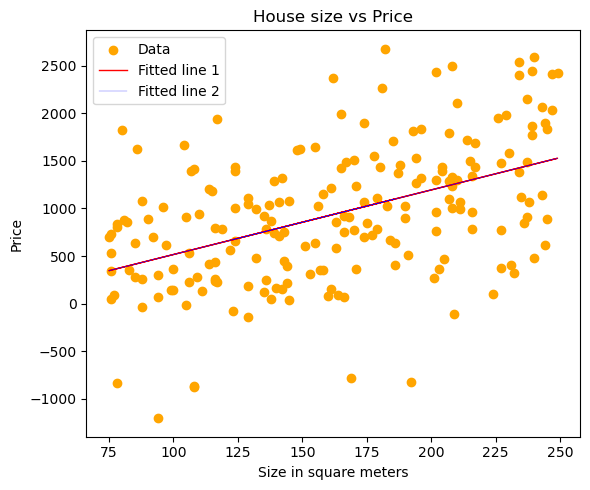


Manual Confidence Intervals
Intercept CI: (np.float64(-465.41625980944536), np.float64(135.88291648060567))
Slope CI:     (np.float64(5.037368870699407), np.float64(8.563723962282825))

Statsmodels Confidence Intervals
[[-465.41625981  135.88291648]
 [   5.03736887    8.56372396]]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     57.85
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.12e-12
Time:                        22:59:30   Log-Likelihood:                -1575.1
No. Observations:                 200   AIC:                             3154.
Df Residuals:                     198   BIC:                             3161.
Df Model:                           1                                         
Covari

In [14]:
# Generate data
np.random.seed(1616) 
n = 200 # number houses
size = np.random.randint(75,250,n) # independent variable house sizes
X = np.column_stack([np.ones(n),size]) # Regression matrix
beta_0, beta_1 = 9,6 # true coefficients
true_price = X @ np.array([beta_0,beta_1]) # true relationship between house size and price
error = np.random.normal(loc=0,scale=600,size=n) # independent normal distributed errors around 0
price = true_price + error # dependent variable price

# Fit model
beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ price)
model = LinearRegression().fit(X,price)
print(f"Compare coefficients beta_hat = ({beta_hat[0]:.4f},{beta_hat[1]:.4f}) and models beta_hat=({model.intercept_:.4f},{model.coef_[1]:.4f})")

price_hat = X @ beta_hat

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X[:,1],price,color="orange",label="Data")
plt.plot(X[:,1],price_hat,color="red",linewidth=1,label="Fitted line 1")
plt.plot(X[:,1],model.predict(X),color="blue",linewidth=0.2,label="Fitted line 2")
plt.title("House size vs Price")
plt.xlabel("Size in square meters")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

# Compute Var(SSE), Var(beta_0_hat) and Var(beta_1_hat)
df = n-2
SSE = np.sum((price - price_hat)**2)
Var_SSE = SSE / df
mean_size = np.mean(size)
mean_price = np.mean(price)
Var_beta_0_hat = Var_SSE * (1/n + (mean_size**2) / np.sum((size - mean_size)**2))
Var_beta_1_hat = Var_SSE / np.sum((size - mean_size)**2)

# Compute coefficient intervals

# significance level
alpha = 0.05

# critical t value
t_crit = t.ppf(1 - alpha/2, df)

# Confidence intervals (manual)
CI_beta0 = (
    beta_hat[0] - t_crit * np.sqrt(Var_beta_0_hat),
    beta_hat[0] + t_crit * np.sqrt(Var_beta_0_hat)
)

CI_beta1 = (
    beta_hat[1] - t_crit * np.sqrt(Var_beta_1_hat),
    beta_hat[1] + t_crit * np.sqrt(Var_beta_1_hat)
)

print("\nManual Confidence Intervals")
print(f"Intercept CI: {CI_beta0}")
print(f"Slope CI:     {CI_beta1}")

sm_model = sm.OLS(price, X).fit()

print("\nStatsmodels Confidence Intervals")
print(sm_model.conf_int(alpha))
print(sm_model.summary())


#### F-Test for Overall Model Significance

Tests whether the regression model explains variation in $y$ (aka Price).


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Hypotheses (for intercept)</u></h5>

$$
H_0: \beta_0 = b_0 \text{ vs. } H_1: \beta_0 \neq b_0 \hspace{2 mm} \text{ with commonly } b_0 = 0
$$


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Hypotheses (for slope)</u></h5>

$$
H_0: \beta_1 = b_1 \text{ vs. } H_1: \beta_1 \neq b_1 \hspace{2 mm} \text{ with commonly } b_1 = 0
$$



</div>

</div>




<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Hypotheses (for intercept and slope)</u></h5>

$$
H_0: \beta_0 = \beta_1 = b \text{ vs. } H_1: \beta_0 = \beta_1 \neq b \hspace{2 mm} \text{ with commonly } b = 0
$$



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">




</div>

</div>







<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Test Statistic (for intercept)</u></h5>

$$
F_0 = t_0^2 
$$


$$
F_0 = \frac{(\hat{\beta_0} - b_0)\left(\frac{1}{n}  +\frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}\right)^{-1}(\hat{\beta_0} - b_0)}{\mathrm{Var}(\text{SSE})}
$$


$$
F_0 = \frac{(\text{SSE}_R - \text{SSE}) / q}{\mathrm{Var}(\text{SSE})} \hspace{2 mm} \text{ with } q = 1
$$

$\text{SSE}_R$ denotes the $\text{SSE}$ of the **restricted** model. Since we hypothesize that $\beta_0 = b_0 = 0$ the model changes from $\text{Price}_i = \beta_0 + \beta_1 \text{Size}_i + \varepsilon_i$ to $\text{Price}_i = \beta_1 \text{Size}_i \varepsilon_i$ and therefor our predictions change from $\widehat{\text{Price}}_i = \hat{\beta_0} + \hat{\beta_1} \text{Size}_i$ to $\widehat{\text{Price}}_i = \hat{\beta_1} \text{Size}_i$. 
This results in $\text{SSE}_R = \sum_{i=1}^n (\text{Price}_i - \widehat{\text{Price}}_i)^2 = \sum_{i=1}^n (\text{Price}_i-hat{\beta_1} \text{Size}_i)^2.$
To compute only $\hat{\beta_1}$ disgard intercept column in Regression matrix.



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Test Statistic (for slope)</u></h5>


$$
F_1 = t_1^2
$$


$$
F_1 = \frac{(\hat{\beta_1} - b_1)\left(\frac{1}{\sum_{i=1}^n (x_i - \bar{x})^2}\right)^{-1}(\hat{\beta_1} - b_1)}{\mathrm{Var}(\text{SSE})}
$$


$$
F_1 = \frac{\frac{\text{SSR}}{2-1}}{\frac{SSE}{n-2}} 
$$

We divide $\text{SSR}$ by $2-1$ because $\text{SSR} = \sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2$  and $\hat{y}_i=\hat{\beta_0} + \hat{\beta_1} \cdot x$ has 2 free parameters and $\bar{y}$ is just one value.


</div>

</div>


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Test Statistic (for intercept slope)</u></h5>

$$
F_{01} = \frac{(\text{SSE}_R - \text{SSE}) / q}{\mathrm{Var}(\text{SSE})} \hspace{2 mm} \text{ with } q = 2
$$

$$
\text{or in matrix form}
$$

$$
F_{01} = \frac{(\hat{\beta}-b)^\top(X^\top X)(\hat{\beta}-b) / q}{\mathrm{Var}(\text{SSE})} \hspace{2 mm} \text{ with } q = 2
$$

$\text{SSE}_R$ denotes the $\text{SSE}$ of the **restricted** model. Since we hypothesize that $\beta_0 = \beta_1 = b = 0$ the model changes from $\text{Price}_i = \beta_0 + \beta_1 \text{Size}_i + \varepsilon_i$ to $\text{Price}_i = \varepsilon_i$ and therefor our predictions change from $\widehat{\text{Price}}_i = \hat{\beta_0} + \hat{\beta_1} \text{Size}_i$ to $\widehat{\text{Price}}_i = 0$. 
This results in $\text{SSE}_R = \sum_{i=1}^n (\text{Price}_i - \widehat{\text{Price}}_i)^2 = \sum_{i=1}^n (\text{Price}_i-0)^2 $


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">




</div>

</div>


| Hypothesis                | Restrictions |
| ------------------------- | ------------ |
| $\beta_0 = 0$           | **1**            |
| $\beta_1 = 0$           | **1**            |
| $\beta_0 = \beta_1 = 0$ | **2**        |




##### Distribution of $F_{0,1}$

>Similar to the distribution of the $t$-test statistics explained above, we need to know which values of the $F$-test statistic are expected if the null hypothesis is true. If we repeatedly collect many datasets where the true coefficients satisfy the null hypothesis and compute the corresponding $F$-statistics, these values follow an $F$-distribution.
The $F$-distribution has degrees of freedom $(q,n-k)$ where $q$ is the number of restrictions and $k$ is the number of parameters in the full model. Unlike the Student $t$distribution, the $F$-distribution cannot take negative values because it is based on ratios of squared quantities.
Using a significance level $\alpha$, we define a critical value in the right tail of the distribution. If the computed $F$-statistic exceeds this value, the result would be unlikely under $H_0$, and we reject the null hypothesis.



In [15]:
from scipy.stats import f # for F ddistribution

Manually estimated intercept -123.2313 and slope 4.7845 compared to model intercept -123.2313 and slope 4.7845
Compare estimated R^2 = 0.2074 with model score R^2 = 0.207427


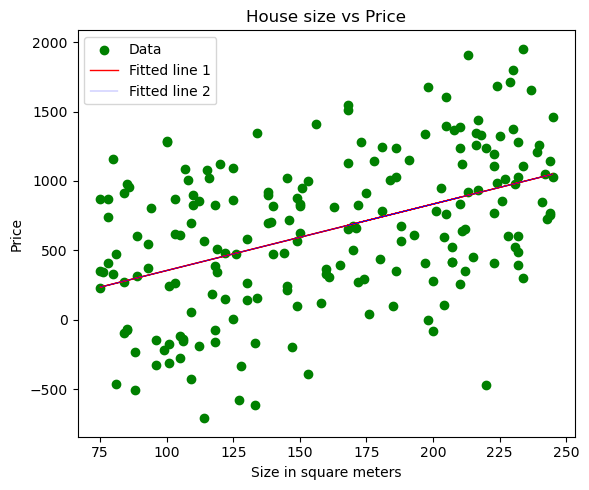

Compare coefficients beta_0_hat=0 and beta_1_hat=4.0894 | beta_0_hat=0.0 and beta_1_hat=4.0894


--- Manual F statistics ---
F0_short (t0^2):        1.209434
F0_mid (SSE formula):   1.209434
F0_long (matrix form):  1.209434

Intercept pvalue: 0.2727795326331056
F1_short (t1^2):        51.819149
F1_mid (SSR formula):   51.819149
F1_long (matrix form):  51.819149

Slope p value: 1.2348011502183454e-11
F01_matrix:             198.345641
F01_SSE:                198.345641
Joint p value: 1.1102230246251565e-16

--- Statsmodels tests ---
F-test beta0 = 0
<F test: F=1.2094341277671727, p=0.27277953263310806, df_denom=198, df_num=1>
p-value intercept: 0.27277953263310806

F-test beta1 = 0
<F test: F=51.81914889820545, p=1.2347993259968394e-11, df_denom=198, df_num=1>
F-statistic (slope test): 51.81914889820552 with p-value Prob(F-statistic): 1.234799325996787e-11

F-test beta0 = beta1 = 0
<F test: F=198.34564146854675, p=5.187858814857092e-48, df_denom=198, df_num=2>
                          

In [16]:
# Generate data
np.random.seed(1153) # for reproducibility
n = 200 # number of houses
house_size = np.random.randint(75,250,n) # house sizes in square meters
beta_0, beta_1 = 3,4 # true coefficients
true_price = beta_0 + beta_1 * house_size # true relationship between house size and price
error = np.random.normal(loc=0,scale=500,size=n) # independent normally distributed errors around 0
price = true_price + error # distorted relationship between house sizes and price


# Fit model
mean_size = np.mean(house_size) 
mean_price = np.mean(price)
beta_1_hat = np.sum((house_size - mean_size)*(price - mean_price)) / np.sum((house_size - mean_size)**2)
beta_0_hat = mean_price - beta_1_hat * mean_size
X = np.column_stack((np.ones(n), house_size))
model = LinearRegression().fit(X,price)
print(f"Manually estimated intercept {beta_0_hat:.4f} and slope {beta_1_hat:.4f} compared to model intercept {model.intercept_:.4f} and slope {model.coef_[1]:.4f}")



# Make predictions and compute SSE as well as R2
price_hat = beta_0_hat + beta_1_hat * house_size
error_hat = price - price_hat
SSE = np.sum(error_hat**2)
SST = np.sum((price - mean_price)**2)
SSR = np.sum((price_hat - mean_price)**2)
R2 = SSR / SST
print(f"Compare estimated R^2 = {R2:.4f} with model score R^2 = {model.score(X,price):4f}")


# Plot
plt.figure(figsize=(6,5))
plt.scatter(house_size,price,color="green",label="Data")
plt.plot(house_size,price_hat,color="red",linewidth=1,label="Fitted line 1")
plt.plot(house_size,model.predict(X),color="blue",linewidth=0.2,label="Fitted line 2")
plt.title("House size vs Price")
plt.xlabel("Size in square meters")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()



# Calculate Var(SSE), Var(beta_0_hat), Var(beta_1_hat), t_0 and t_1 
df = n-2
Var_SSE = SSE / df
Var_beta_0_hat = Var_SSE * (1/n + (mean_size**2) / np.sum((house_size - mean_size)**2))
Var_beta_1_hat = Var_SSE / np.sum((house_size - mean_size)**2)
t_0 = (beta_0_hat - 0) / np.sqrt(Var_beta_0_hat)
t_1 = (beta_1_hat - 0) / np.sqrt(Var_beta_1_hat)



# Calculate F_0 in 3 ways with Hypothesis H0:beta_0 = 0
F_0_short = t_0**2

X_restricted = house_size.reshape(-1,1)
beta_hat = np.linalg.inv(X_restricted.T @ X_restricted) @ X_restricted.T @ price
model_restricted = LinearRegression(fit_intercept=False).fit(X_restricted, price)
print(f"Compare coefficients beta_0_hat={0} and beta_1_hat={beta_hat[0]:.4f} | beta_0_hat={model_restricted.intercept_} and beta_1_hat={model_restricted.coef_[0]:.4f}\n")
#price_hat_restricted = model_restricted.predict(X_restricted)
price_hat_restricted = beta_hat[0] * house_size
SSE_R = np.sum((price - price_hat_restricted)**2) # restricted model: y = 0
F_0_mid = ((SSE_R-SSE)/1)/Var_SSE

F_0_long = ((beta_0_hat-0)*((1/n + (mean_size**2) / np.sum((house_size - mean_size)**2))**(-1))*(beta_0_hat-0)) / (Var_SSE)



# Calculate F_1 in 3 ways with Hypothesis H0:beta_1 = 0
F_1_short = t_1**2
F_1_mid = (SSR/(2-1)) / (SSE / (n-2))
F_1_long = ((beta_1_hat)*((1 / np.sum((house_size - mean_size)**2))**(-1))*(beta_1_hat)) / Var_SSE


# Calculate F_0,1 in 2 ways with Hypothesis H0:beta_1 = beta_0 = 0
beta_vec = np.array([beta_0_hat, beta_1_hat])
F_01_matrix = (beta_vec.T @ (X.T @ X) @ beta_vec / 2) / Var_SSE

SSE_restricted = np.sum(price**2) # restricted model: y = 0
F_01 = ((SSE_restricted - SSE)/2) / (SSE/(n-2))


# Compare results of F-test statistics

q = 1 # number of restrictions
k = 2  # parameters in full model (intercept + slope)
df1 = q
df2 = n - k

print("\n--- Manual F statistics ---")

p_F0 = 1 - f.cdf(F_0_short, df1, df2) # Prob(F-statistic) for intercept test
print(f"F0_short (t0^2):        {F_0_short:.6f}")
print(f"F0_mid (SSE formula):   {F_0_mid:.6f}")
print(f"F0_long (matrix form):  {F_0_long:.6f}\n")
print("Intercept pvalue:", p_F0)


p_F1 = 1 - f.cdf(F_1_short, df1, df2) # Prob(F-statistic) for slope test
print(f"F1_short (t1^2):        {F_1_short:.6f}")
print(f"F1_mid (SSR formula):   {F_1_mid:.6f}")
print(f"F1_long (matrix form):  {F_1_long:.6f}\n")
print("Slope p value:", p_F1)

# Joint test
q_joint = 2
p_F01 = 1 - f.cdf(F_01, q_joint, n-k)
print(f"F01_matrix:             {F_01_matrix:.6f}")
print(f"F01_SSE:                {F_01:.6f}")
print("Joint p value:", p_F01) 



sm_model = sm.OLS(price, X).fit()
print("\n--- Statsmodels tests ---")

print("F-test beta0 = 0")
print(sm_model.f_test("const = 0"))
f_intercept = sm_model.f_test("const = 0")
print("p-value intercept:", float(f_intercept.pvalue))


print("\nF-test beta1 = 0")
print(sm_model.f_test("x1 = 0"))
print("F-statistic (slope test):", sm_model.fvalue, "with p-value Prob(F-statistic):",sm_model.f_pvalue)

print("\nF-test beta0 = beta1 = 0")
print(sm_model.f_test("const = 0, x1 = 0"))



print(sm_model.summary(),"\n")


<a class="anchor" id="gd"></a>
## 6. (Batch) Gradient Descent


**Gradient descent (also called Batch Gradient descednt) is an iterative optimization algorithm often used to minimize the risk.**

Here we use he Sum of squared errors as risk
$$
SSE = \sum_{i=1}^n \hat{\varepsilon_i}^2 = \sum_{i=1}^{n}(\text{Price}_i - \widehat{\text{Price}}_i)^2 = \underbrace{\sum_{i=1}^{n}(\text{Price}_i - (\beta_0 + \beta_1 \cdot \text{Size}_i))^2}_{\sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 \cdot x_i))^2}
$$

Instead of checking every parameter combination, we:


1. Start with random parameters for $\beta_0$ and $\beta_1$
2. Compute the gradient with respect to $\beta_0$ and $\beta_1$ at some points $\beta_0^{[t]}$ and $\beta_1^{[t]}$
    - $\nabla \text{SSE}(\beta_0^{[t]}) = \frac{\partial \text{SSE}}{ \partial \beta_0}(\beta_0^{[t]})$
    - $\nabla \text{SSE}(\beta_1^{[t]}) = \frac{\partial \text{SSE}}{ \partial \beta_1}(\beta_1^{[t]})$
    - $\nabla \text{SSE} = \begin{pmatrix} \frac{\partial \text{SSE}}{ \partial \beta_0} & \frac{\partial \text{SSE}}{ \partial \beta_1}\end{pmatrix}^\top$
     
     
3. Move in the direction that reduces error with $-\frac{\partial \text{SSE}}{ \partial \beta_0}(\beta_0^{[t]})$,$-\frac{\partial \text{SSE}}{ \partial \beta_1}(\beta_1^{[t]})$ and control step size with $\alpha$

    - Update rule:

    $$
    \beta_0^{[t+1]}=\beta_0^{[t]} -\alpha \frac{\partial \text{SSE}}{ \partial \beta_0}(\beta_0^{[t]}) 
    $$
    
    $$
    \beta_1^{[t+1]}=\beta_1^{[t]} -\alpha \frac{\partial \text{SSE}}{ \partial \beta_1}(\beta_1^{[t]}) 
    $$


    - Where:
        - $\alpha \rightarrow$ learning rate
        - gradient $\frac{\partial \text{SSE}}{ \partial \beta_0}(\beta_0^{[t]})  \rightarrow$ direction of steepest increase at point $\beta_0^{[t]}$ (same for $\beta_1$)
        - move opposite direction, so in direction with steepest decrease $\rightarrow -\frac{\partial \text{SSE}}{ \partial \beta_0}(\beta_0^{[t]})$ and control step sizes $\rightarrow -\alpha \frac{\partial \text{SSE}}{ \partial \beta_0}(\beta_0^{[t]})$

4. Repeat until convergence (i.e. updated $\theta$ does not change much or gradient approaches 0)


##### Local vs Global Minimum

A local minimum is a point where *small changes increase error* but it might not be the best overall minimum.

**Definition of local minimum for parameter vector $\hat{\beta}=(\hat{\beta_0},\hat{\beta_1})^\top$:**
 
$\quad \quad \hat{\beta}$ is a local minimum if $\exists \epsilon \ge 0 \hspace{1mm} \forall \theta$ with $\lVert \hat{\beta}-\beta \rVert \le \epsilon : \text{SSE}_{\hat{\beta}} \leq \text{SSE}_\beta$ or in other words $\text{SSE}_{\hat{\beta}} \leq \text{SSE}_\beta$ for all nearby $\beta$


Gradient descent may stop at:

- local minimum
- global minimum
- saddle point

depending on the error surface and the random start parameters.

<p align="center">
<img src="local_global_min.jpg" width="350"/>
</p>


##### Local minimum sufficient conditions
Given that $\text{SSE}$ is continuously differentiable with respect to $\beta_0$ and $\beta_1$ we have two conditions:
1. $\hat{\beta}=(\hat{\beta_0},\hat{\beta_1})^\top$ is stationary meaning $\frac{\partial \text{SSE}}{ \partial \beta_0}(\hat{\beta_0})=\frac{\partial \text{SSE}}{ \partial \beta_1}(\hat{\beta_1}) =0$
2. Hessian $\nabla^2  \text{SSE}$ at $\hat{\beta}$ is positive definite meaning  

$$
z^\top \nabla^2    \text{SSE } z =
z^\top \begin{pmatrix} 
\frac{\partial \text{SSE}}{\partial \beta_0 \partial \beta_0}(\hat{\beta}) & \frac{\partial \text{SSE}}{\partial \beta_0 \partial \beta_1}(\hat{\beta})  \\ 

\frac{\partial \text{SSE}}{\partial \beta_1 \partial \beta_0}(\hat{\beta}) & \frac{\partial \text{SSE}}{\partial \beta_1 \partial \beta_1}(\hat{\beta})


\end{pmatrix} z \geq 0 \hspace{1 mm} \text{ for all }z \neq \begin{pmatrix} 0 \\ \vdots \\ 0 \end{pmatrix}
$$


##### Learning rate $\alpha$

The learning rate controls step size.

<div style="display:flex; gap:20px;">

<!-- Intercept -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Small $\alpha$
- slow convergence
- stable

</div>


<!-- Slope -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Good $\alpha$
- fast convergence

</div>


<!-- Example or other test -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Too large $\alpha$
- overshoot minimum
- algorithm may diverge

</div>

</div>

##### Limitations of Gradient Descent

When working with large datasets, standard (batch) gradient descent has some important limitations:

- High computational cost
    - Each update requires computing the gradient using all data points, which becomes very slow when the number of observations is large.

- Memory inefficiency
    - Loading the entire dataset into memory for every update can be impractical for very large datasets.

- Slow updates
    - Since updates happen only after processing the full dataset, learning can be slow and inflexible, especially in early stages.


##### Stochastic Gradient Descent (SGD) as a Solution

Stochastic Gradient Descent (SGD) addresses these issues by updating parameters using one data point at a time (or small batches):

$$
\beta_i^{[t+1]}=\beta_i^{[t]} -\alpha \nabla \frac{\partial \text{SSE}}{ \partial \beta_i}(\beta_i^{[t]}) \hspace{1mm}, \hspace{2mm} i=0,1 
$$

- Much faster updates
    - Parameters are updated after each observation $\rightarrow$ quicker learning

- Scales to large datasets
    - No need to process all data at once

- Lower memory usage
    - Works well even when data does not fit in memory

- Adds beneficial randomness
    - The noise in updates can help escape local minima and saddle points


Trade-off
- SGD is faster but noisier
- Batch GD is stable but slow

$$
\begin{align}
\frac{\partial \text{SSE}}{ \partial \beta_0} 
&= \frac{\partial}{ \partial \beta_0} \sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 \cdot x_i))^2  \\
&=  \sum_{i=1}^{n}  \frac{\partial}{ \partial \beta_0} (y_i - (\beta_0 + \beta_1 \cdot x_i))^2  \\
&=  \sum_{i=1}^{n}   2 \cdot (y_i - (\beta_0 + \beta_1 \cdot x_i)) \frac{\partial}{ \partial \beta_0} (y_i - \beta_0 - \beta_1 \cdot x_i)  \\
&=  \sum_{i=1}^{n} 2 \cdot (y_i - (\beta_0 + \beta_1 \cdot x_i))  (-1)  \\
&=  \sum_{i=1}^{n} -2 \cdot (y_i - (\beta_0 + \beta_1 \cdot x_i)) 
\end{align}
$$



$$
\begin{align}
\frac{\partial \text{SSE}}{ \partial \beta_1} 
&= \frac{\partial}{ \partial \beta_1} \sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 \cdot x_i))^2  \\
&=  \sum_{i=1}^{n}  \frac{\partial}{ \partial \beta_1} (y_i - (\beta_0 + \beta_1 \cdot x_i))^2  \\
&=  \sum_{i=1}^{n}  2 \cdot (y_i - (\beta_0 + \beta_1 \cdot x_i)) \frac{\partial}{ \partial \beta_1} (y_i - \beta_0 - \beta_1 \cdot x_i)  \\
&=  \sum_{i=1}^{n}  -2 \cdot x_i \cdot (y_i - (\beta_0 + \beta_1 \cdot x_i))   \\

\end{align}
$$

In [17]:
from mpl_toolkits.mplot3d import Axes3D # for surface plotting

# data
height = np.array([1.4,1.9,3.2]) 
weight = np.array([0.5,2.3,2.9])

A,B = np.meshgrid(weight, height)

print(A)
print()
print(B)

np.meshgrid(weight, height)

[[0.5 2.3 2.9]
 [0.5 2.3 2.9]
 [0.5 2.3 2.9]]

[[1.4 1.4 1.4]
 [1.9 1.9 1.9]
 [3.2 3.2 3.2]]


(array([[0.5, 2.3, 2.9],
        [0.5, 2.3, 2.9],
        [0.5, 2.3, 2.9]]),
 array([[1.4, 1.4, 1.4],
        [1.9, 1.9, 1.9],
        [3.2, 3.2, 3.2]]))

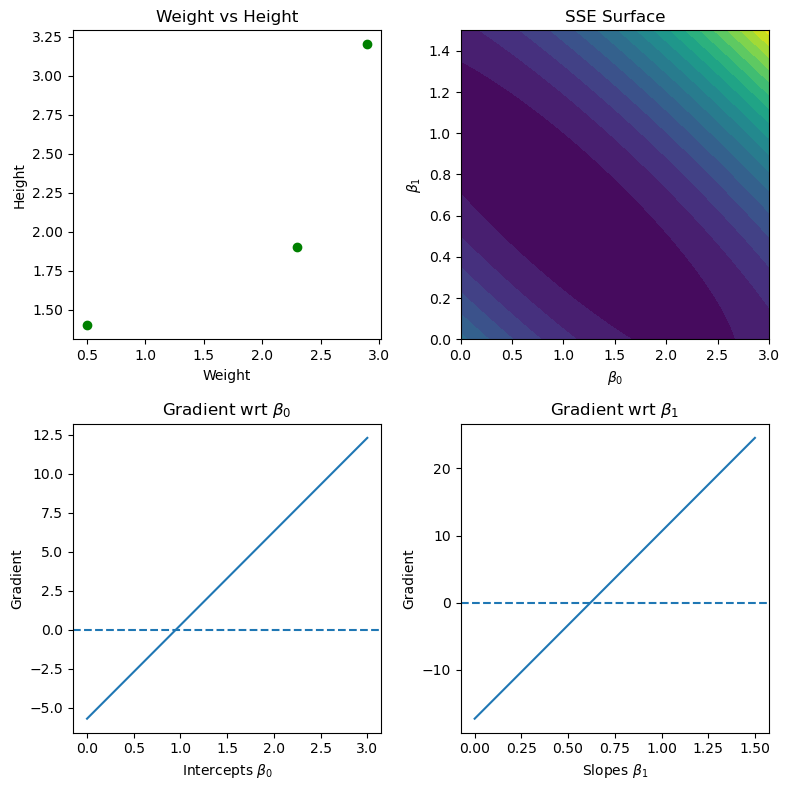

In [18]:
# gradient beta_0
def grad_beta0(beta0, beta1):
    return -2 * np.sum(height - (beta0 + beta1 * weight))

# gradient beta_1
def grad_beta1(beta0, beta1):
    return -2 * np.sum(weight * (height - (beta0 + beta1 * weight)))

# SSE function
def SSE(beta0, beta1):
    return np.sum((height - (beta0 + beta1 * weight))**2)


# parameter grids
beta0_vals = np.linspace(0, 3, 100)
beta1_vals = np.linspace(0, 1.5, 100)


B0, B1 = np.meshgrid(beta0_vals, beta1_vals)

# compute SSE surface
Z = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        Z[i, j] = SSE(B0[i, j], B1[i, j])

plt.figure(figsize=(8,8))

# Scatter plot of data
plt.subplot(2,2,1)
plt.scatter(weight, height, color="green")
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Weight vs Height")

# 3D Risk surface
plt.subplot(2,2,2)
plt.contourf(B0, B1, Z, levels=20)
plt.xlabel(r"$\beta_0$")
plt.ylabel(r"$\beta_1$")
plt.title("SSE Surface")

# Gradient wrt beta_0 (fix beta_1)
beta1_fixed = 0.64
grad0_vals = [grad_beta0(b0, beta1_fixed) for b0 in beta0_vals]

plt.subplot(2,2,3)
plt.plot(beta0_vals, grad0_vals)
plt.axhline(0, linestyle="--")
plt.xlabel("Intercepts $\\beta_0$")
plt.ylabel("Gradient")
plt.title("Gradient wrt $\\beta_0$")

# Gradient wrt beta_1 (fix beta_0)
beta0_fixed = 1
grad1_vals = [grad_beta1(beta0_fixed, b1) for b1 in beta1_vals]

plt.subplot(2,2,4)
plt.plot(beta1_vals, grad1_vals)
plt.axhline(0, linestyle="--")
plt.xlabel("Slopes $\\beta_1$")
plt.ylabel("Gradient")
plt.title("Gradient wrt $\\beta_1$")

plt.tight_layout()
plt.show()

Converged in 179 iterations


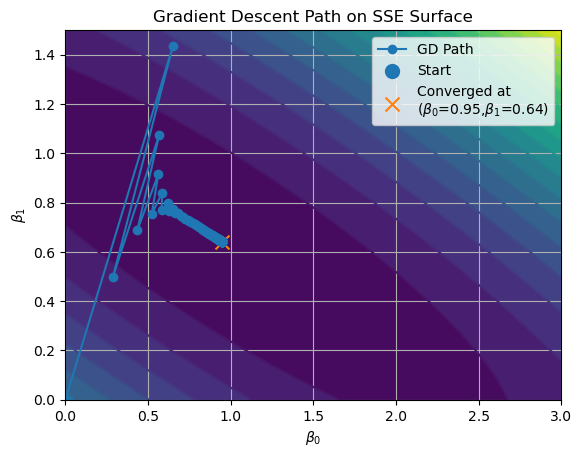

In [19]:
# Gradient Descent 
beta0, beta1 = 0.0, 0.0 # start point
alpha = 0.05 # learning rate
epsilon = 1e-6 # tolerance
max_iter = 1000

# store path
beta0_hist = []
beta1_hist = []

for i in range(max_iter):

    beta0_hist.append(beta0)
    beta1_hist.append(beta1)

    # compute gradients
    g0 = grad_beta0(beta0, beta1)
    g1 = grad_beta1(beta0, beta1)

    # update
    new_beta0 = beta0 - alpha * g0
    new_beta1 = beta1 - alpha * g1

    # stopping condition
    if np.sqrt((new_beta0 - beta0)**2 + (new_beta1 - beta1)**2) < epsilon: # if change in new beta and beta is very small
        print(f"Converged in {i} iterations")
        break

    beta0, beta1 = new_beta0, new_beta1


# contour surface
plt.contourf(B0, B1, Z, levels=20)
plt.contour(B0, B1, Z, levels=20)

# gradient descent path
plt.plot(beta0_hist, beta1_hist, marker='o', label="GD Path")

# start point
plt.scatter(beta0_hist[0], beta1_hist[0],
            s=100, label="Start")

# end point
plt.scatter(beta0_hist[-1], beta1_hist[-1],
            s=100, marker='x', label=f"Converged at\n($\\beta_0$={beta0_hist[-1]:.2f},$\\beta_1$={beta1_hist[-1]:.2f})")

plt.xlabel(r"$\beta_0$")
plt.ylabel(r"$\beta_1$")
plt.title("Gradient Descent Path on SSE Surface")
plt.legend()
plt.grid()

plt.show()

<a class="anchor" id="sgd"></a>
## 7. Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent (SGD) is a variant of gradient descent that updates parameters using only one observation (or a small subset) at each iteration.

Instead of computing the gradient over the full dataset, we approximate the risk using a single data point:

$$
\text{SSE}_i = (y_i - (\beta_0 + \beta_1 \cdot x_i))^2
$$


Instead of batch updates, we:

1. Start with random parameters for $\beta_0$ and $\beta_1$

2. At each iteration, randomly select a data point $(x_i, y_i)$

3. Compute the gradient using only this observation:

    - $\frac{\partial SSE_i}{\partial \beta_0} = -2 (y_i - (\beta_0 + \beta_1 x_i))$
    - $\frac{\partial SSE_i}{\partial \beta_1} = -2 x_i (y_i - (\beta_0 + \beta_1 x_i))$
    - Gradient vector: $$\nabla \text{SSE}_i = \begin{pmatrix} \frac{\partial \text{SSE}_i}{ \partial \beta_0} \\ \frac{\partial \text{SSE}_i}{ \partial \beta_1}\end{pmatrix}$$

4. Update parameters using this noisy gradient:

    $$
    \beta_0^{[t+1]}=\beta_0^{[t]} -\alpha \frac{\partial \text{SSE}_i}{ \partial \beta_0}(\beta_0^{[t]}) 
    $$
    
    $$
    \beta_1^{[t+1]}=\beta_1^{[t]} -\alpha \frac{\partial \text{SSE}_i}{ \partial \beta_1}(\beta_1^{[t]}) 
    $$

Where:

- $\alpha \rightarrow$ learning rate
- Gradient is now based on a single observation, not the full dataset
- Updates are noisy approximations of the true gradient

Repeat until convergence

- Continue sampling observations and updating parameters
- Convergence is reached when parameters stabilize on average
- The path will oscillate around the minimum rather than smoothly converge


**Comparison to Batch Gradient Descent**
<div style="display:flex; gap:20px;"> <div style="padding:16px; width:50%;">

Batch Gradient Descent

- Uses all data points
- Smooth convergence
- Computationally expensive

</div> <div style="padding:16px; width:50%;">

Stochastic Gradient Descent

- Uses one data point
- Noisy updates
- Much faster and scalable

</div> </div>


**Mini-batch Gradient Descent (Practical Compromise)**

In practice, we often use mini-batch gradient descent, which updates parameters using a small subset of data:

$$
\beta^{[t+1]}=\beta_1^{[t]} -\alpha \nabla \text{SSE}_\mathcal{B}(\beta^{[t]}) \hspace{1 mm}, \hspace{1 mm} \beta = (\beta_0,\beta_1)^\top
$$

- $\mathcal{B}$ = small batch of observations



**Key takeaway**

Batch GD follows a smooth path directly downhill, while SGD behaves like a noisy but fast descent, often reaching a good solution much quicker.

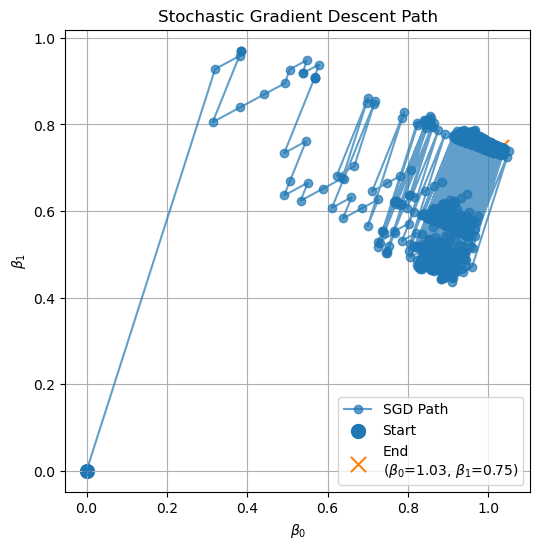

In [20]:
np.random.seed(1701)

# data
height = np.array([1.4,1.9,3.2]) 
weight = np.array([0.5,2.3,2.9])

# SGD gradients (single point)
def sgd_grad_beta0(beta0, beta1, x_i, y_i):
    return -2 * (y_i - (beta0 + beta1 * x_i))

def sgd_grad_beta1(beta0, beta1, x_i, y_i):
    return -2 * x_i * (y_i - (beta0 + beta1 * x_i))


# SGD
beta0, beta1 = 0,0
alpha = 0.05
epsilon = 1e-6
max_iter = 1000

beta0_hist = []
beta1_hist = []

n = len(weight)

for i in range(max_iter):

    beta0_hist.append(beta0)
    beta1_hist.append(beta1)

    # pick random data point
    idx = np.random.randint(0, n)
    x_i = weight[idx]
    y_i = height[idx]

    # compute stochastic gradients
    g0 = sgd_grad_beta0(beta0, beta1, x_i, y_i)
    g1 = sgd_grad_beta1(beta0, beta1, x_i, y_i)

    # update
    new_beta0 = beta0 - alpha * g0
    new_beta1 = beta1 - alpha * g1

    # stopping condition
    if np.sqrt((new_beta0 - beta0)**2 + (new_beta1 - beta1)**2) < epsilon:
        print(f"Converged in {i} iterations")
        break

    beta0, beta1 = new_beta0, new_beta1


# Plot parameter path
plt.figure(figsize=(6,6))
plt.plot(beta0_hist, beta1_hist, marker='o', alpha=0.7, label="SGD Path")

# plot start of parameter path
plt.scatter(beta0_hist[0], beta1_hist[0],
            s=100, label="Start")

# plot end of parameter path
plt.scatter(beta0_hist[-1], beta1_hist[-1],
            s=120, marker='x',
            label=f"End\n($\\beta_0$={beta0_hist[-1]:.2f}, $\\beta_1$={beta1_hist[-1]:.2f})")

plt.xlabel(r"$\beta_0$")
plt.ylabel(r"$\beta_1$")
plt.title("Stochastic Gradient Descent Path")
plt.legend()
plt.grid()

plt.show()